<a href="https://colab.research.google.com/github/Kri520/GroundWater_Quality-in-Rajasthan/blob/main/Groundwater_Quality_ML_Rajasthan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1 · Environment setup



In [1]:
import os, sys, json, math, warnings, textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)
np.set_printoptions(suppress=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", context="notebook")
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 160, "figure.facecolor": "white",
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.labelsize": 10,
    "font.family": "DejaVu Sans",
})
PALETTE = ["#2a9d8f", "#8ab17d", "#e9c46a", "#f4a261", "#e76f51"]

# ---- optional libraries -------------------------------------------------
HAS = {}
for _lib in ["xgboost", "lightgbm", "catboost", "shap", "optuna", "folium", "imblearn"]:
    try:
        __import__(_lib); HAS[_lib] = True
    except Exception:
        HAS[_lib] = False

print("Python      :", sys.version.split()[0])
print("pandas      :", pd.__version__)
import sklearn; print("scikit-learn:", sklearn.__version__)
print("optional    :", {k: ("yes" if v else "no") for k, v in HAS.items()})

Python      : 3.13.15
pandas      : 2.2.3
scikit-learn: 1.6.1
optional    : {'xgboost': 'yes', 'lightgbm': 'yes', 'catboost': 'no', 'shap': 'yes', 'optuna': 'no', 'folium': 'yes', 'imblearn': 'yes'}


In [2]:
# Reproducible output folders
OUT = Path("outputs"); OUT.mkdir(exist_ok=True)
(OUT / "figures").mkdir(exist_ok=True)
(OUT / "models").mkdir(exist_ok=True)
(OUT / "tables").mkdir(exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(OUT / "figures" / f"{name}.png", bbox_inches="tight")

## 2 · Load the raw CGWB file


In [3]:
CSV_PATH = "/content/gwq_chemical_parameter_manual_cgwb_rj_1961_2025.csv"   # <-- change if needed

for _p in [CSV_PATH,
           "1789986757137_gwq_chemical_parameter_manual_cgwb_rj_1961_2025.csv",
           "/mnt/user-data/uploads/1789986757137_gwq_chemical_parameter_manual_cgwb_rj_1961_2025.csv"]:
    if os.path.exists(_p):
        CSV_PATH = _p; break

raw = pd.read_csv(CSV_PATH, na_values=["", "-", "NA", "N/A", "null"], keep_default_na=True)
print(f"Loaded: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.head(3)

Loaded: 12,350 rows x 46 columns


,SlNo,Station,Agency,State LGD Code,State,District LGD Code,District,Tehsil,Block,Village,River,Basin,Tributary,Subtributary,SubSubtributary,Local River,Latitude,Longitude,Data Acquisition Time,Potential of Hydrogen (pH),Electric Conductivity (μS/cm),Total Dissolved Solids (mg/L),Carbonate (mg/L),Bicarbonate (mg/L),Total Alkalinity (mg/L as CaCO3),Chloride (mg/L),Nitrate N (mgN/L),Sulphate (mg/L),Phosphate(mg/L),Silica(mg/L),Fluoride (mg/L),Total Hardness (mgCaCO3/L),Calcium (mg/L),Magnesium (mg/L),Sodium (mg/L),Potassium (mg/L),Iron(mg/L),Arsenic (mg/L),Uranium(mg/L),Manganese (mg/L),Copper (mg/L),Lead (mg/L),Zinc (mg/L),Nickel (mg/L),Cadmium (mg/L),Chromium (mg/L)
0,1,22GB CHAK,CGWB,8,Rajasthan,100,GANGANAGAR,ANUPGARH,ANUPGARH,22GB CHAK,NaN,NaN,NaN,NaN,NaN,NaN,29.263889,73.591667,25-05-2001 00:00,7.74,780.0,NaN,0.0,403.0,330.30,21.0,NaN,57.0,NaN,NaN,NaN,285.0,36.0,47.0,64.0,NaN,0.040,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,22GB CHAK,CGWB,8,Rajasthan,100,GANGANAGAR,ANUPGARH,ANUPGARH,22GB CHAK,NaN,NaN,NaN,NaN,NaN,NaN,29.263889,73.591667,25-05-2004 00:00,8.22,1215.0,NaN,0.0,537.0,440.20,50.0,NaN,120.0,NaN,NaN,NaN,320.0,72.0,34.0,145.0,NaN,4.930,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,22GB CHAK,CGWB,8,Rajasthan,100,GANGANAGAR,ANUPGARH,ANUPGARH,22GB CHAK,NaN,NaN,NaN,NaN,NaN,NaN,29.263889,73.591667,25-05-2015 00:00,8.14,828.0,NaN,0.0,403.0,330.33,57.0,NaN,23.0,NaN,NaN,NaN,280.0,52.0,36.0,70.0,NaN,0.305,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Compact, analysis-friendly column names
RENAME = {
    "Potential of Hydrogen (pH)": "pH",
    "Electric Conductivity (μS/cm)": "EC",
    "Total Dissolved Solids (mg/L)": "TDS",
    "Carbonate (mg/L)": "CO3",
    "Bicarbonate (mg/L)": "HCO3",
    "Total Alkalinity (mg/L as CaCO3)": "ALK",
    "Chloride (mg/L)": "Cl",
    "Nitrate N (mgN/L)": "NO3N",
    "Sulphate (mg/L)": "SO4",
    "Phosphate(mg/L)": "PO4",
    "Silica(mg/L)": "SiO2",
    "Fluoride (mg/L)": "F",
    "Total Hardness (mgCaCO3/L)": "TH",
    "Calcium (mg/L)": "Ca",
    "Magnesium (mg/L)": "Mg",
    "Sodium (mg/L)": "Na",
    "Potassium (mg/L)": "K",
    "Iron(mg/L)": "Fe",
    "Arsenic (mg/L)": "As",
    "Uranium(mg/L)": "U",
    "Manganese (mg/L)": "Mn",
    "Copper (mg/L)": "Cu",
    "Lead (mg/L)": "Pb",
    "Zinc (mg/L)": "Zn",
    "Nickel (mg/L)": "Ni",
    "Cadmium (mg/L)": "Cd",
    "Chromium (mg/L)": "Cr",
}
df = raw.rename(columns=RENAME).copy()

df["date"] = pd.to_datetime(df["Data Acquisition Time"], format="%d-%m-%Y %H:%M", errors="coerce")
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

print("Date range :", df["date"].min().date(), "->", df["date"].max().date())
print("Stations   :", df["Station"].nunique(), "| Districts:", df["District"].nunique())
print("\nSampling month distribution (1 = Jan):")
print(df["month"].value_counts().sort_index())

Date range : 2000-05-25 -> 2024-06-30
Stations   : 1606 | Districts: 34

Sampling month distribution (1 = Jan):
month
5     11965
6       378
9         1
10        4
12        2
Name: count, dtype: int64


## 3 · Data quality audit


,missing_%
Subtributary,100.00
Basin,100.00
Tributary,100.00
SubSubtributary,100.00
Local River,100.00
River,100.00
Ni,100.00
Zn,100.00
Pb,100.00
K,100.00


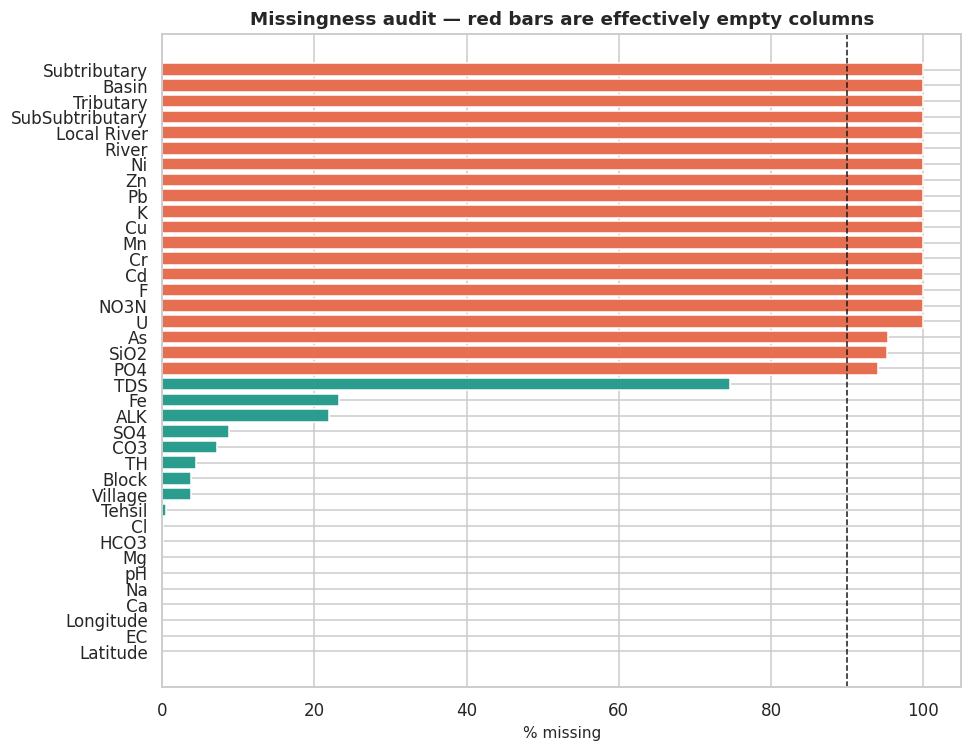

In [5]:
miss = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
miss_tbl = miss.to_frame("missing_%")
display(miss_tbl.head(30))

plt.figure(figsize=(9, 7))
m = miss[miss > 0]
plt.barh(m.index[::-1], m.values[::-1], color=np.where(m.values[::-1] > 90, "#e76f51", "#2a9d8f"))
plt.axvline(90, ls="--", c="k", lw=1)
plt.xlabel("% missing"); plt.title("Missingness audit — red bars are effectively empty columns")
savefig("01_missingness")
plt.show()

In [6]:
# Columns that are 100% empty carry zero information
EMPTY = [c for c in df.columns if df[c].isna().all()]
print("Fully empty columns (dropped):")
print(textwrap.fill(", ".join(EMPTY), 110))
df = df.drop(columns=EMPTY)

Fully empty columns (dropped):
River, Basin, Tributary, Subtributary, SubSubtributary, Local River, NO3N, F, K, Mn, Cu, Pb, Zn, Ni, Cd, Cr


TDS available for 3,130 rows (25.3%)
Pearson r(TDS, EC)        : 0.999329
TDS/EC ratio  25/50/75 pct: {0.25: 0.65, 0.5: 0.65, 0.75: 0.65}
Share of rows with ratio exactly 0.65 : 77.0%


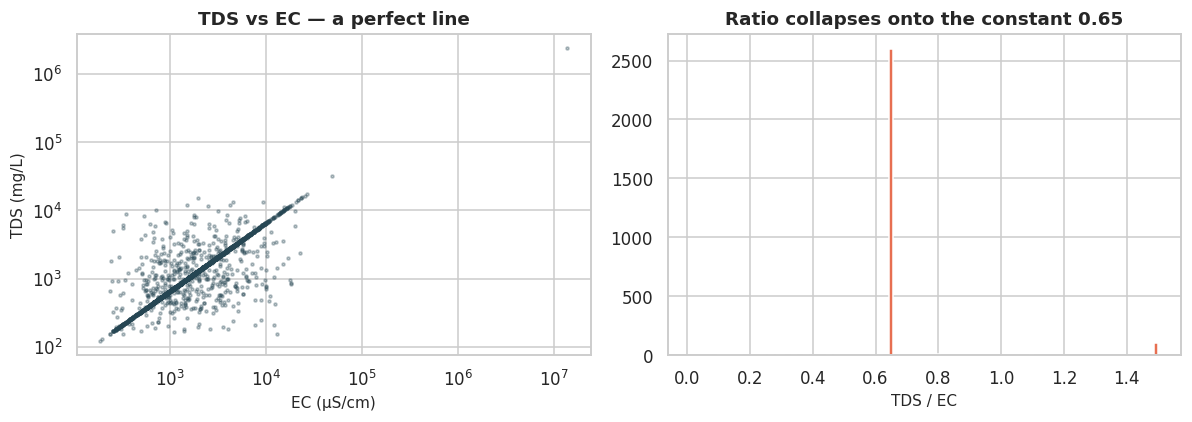

In [7]:

sub = df.dropna(subset=["TDS", "EC"])
ratio = (sub["TDS"] / sub["EC"])
print(f"TDS available for {len(sub):,} rows ({len(sub)/len(df):.1%})")
print(f"Pearson r(TDS, EC)        : {sub['TDS'].corr(sub['EC']):.6f}")
print(f"TDS/EC ratio  25/50/75 pct: {ratio.quantile([.25,.5,.75]).round(4).to_dict()}")
print(f"Share of rows with ratio exactly 0.65 : {(ratio.round(4)==0.65).mean():.1%}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(sub["EC"], sub["TDS"], s=4, alpha=.3, color="#264653")
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("EC (µS/cm)"); ax[0].set_ylabel("TDS (mg/L)"); ax[0].set_title("TDS vs EC — a perfect line")
ax[1].hist(ratio.clip(0, 1.5), bins=120, color="#e76f51")
ax[1].set_xlabel("TDS / EC"); ax[1].set_title("Ratio collapses onto the constant 0.65")
savefig("02_tds_provenance")
plt.show()

In [8]:
df = df.drop(columns=["TDS"])

In [105]:

PLAUSIBLE = {
    "pH":   (4.0, 11.0),   "EC":  (50, 60_000),  "Cl":  (1, 20_000),
    "SO4":  (0, 5_000),    "TH":  (5, 10_000),   "Ca":  (1, 1_500),
    "Mg":   (0.5, 1_500),  "Na":  (1, 8_000),    "HCO3":(0, 2_000),
    "CO3":  (0, 300),      "ALK": (1, 2_000),    "Fe":  (0, 30),
}
audit = []
for col, (lo, hi) in PLAUSIBLE.items():
    if col not in df: continue
    bad = ((df[col] < lo) | (df[col] > hi))
    audit.append({"parameter": col, "valid_range": f"{lo} – {hi}",
                  "impossible_values": int(bad.sum()),
                  "worst_observed": float(df[col].max())})
    df.loc[bad, col] = np.nan
audit = pd.DataFrame(audit).sort_values("impossible_values", ascending=False)
display(audit)
audit.to_csv(OUT / "tables" / "plausibility_audit.csv", index=False)

,parameter,valid_range,impossible_values,worst_observed
0,pH,4.0 – 11.0,0,10.99
1,EC,50 – 60000,0,27500.00
2,Cl,1 – 20000,0,9397.00
3,SO4,0 – 5000,0,5000.00
4,TH,5 – 10000,0,6080.00
5,Ca,1 – 1500,0,1000.00
6,Mg,0.5 – 1500,0,1209.00
7,Na,1 – 8000,0,5200.00
8,HCO3,0 – 2000,0,1964.00
9,CO3,0 – 300,0,186.00


In [10]:

before = df["ALK"].isna().mean()
df["ALK"] = df["ALK"].fillna(0.8202 * df["HCO3"] + 1.6667 * df["CO3"])
print(f"Alkalinity missing: {before:.1%} -> {df['ALK'].isna().mean():.1%} after stoichiometric recovery")

Alkalinity missing: 21.9% -> 4.4% after stoichiometric recovery


In [11]:
# Exact duplicate measurements (same well, same timestamp) are re-entries
dup = df.duplicated(subset=["Station", "Data Acquisition Time"], keep="first")
print(f"Duplicate (station, timestamp) records removed: {dup.sum()}")
df = df[~dup].copy()

Duplicate (station, timestamp) records removed: 50


In [12]:
# The analytical panel we need for a defensible index
CORE = ["pH", "EC", "Cl", "SO4", "TH", "Ca", "Mg", "Na", "ALK", "Fe"]
print("Missingness within the core panel:")
print((df[CORE].isna().mean() * 100).round(2).to_string())

df = df.dropna(subset=CORE + ["Latitude", "Longitude", "date"]).reset_index(drop=True)
print(f"\nComplete-case dataset: {len(df):,} samples across {df['Station'].nunique():,} stations")

Missingness within the core panel:
pH      0.02
EC      0.02
Cl      0.07
SO4     8.84
TH      4.41
Ca      0.07
Mg      0.05
Na      0.07
ALK     4.46
Fe     23.33

Complete-case dataset: 9,408 samples across 1,433 stations


## 4 · Analytical validation — ionic charge balance

A groundwater sample is an electrolyte solution, so the sum of cation charges **must** equal the sum of anion
charges. Converting mg/L to milliequivalents per litre (divide by equivalent weight) lets us compute the
**Charge Balance Error**:

$$\mathrm{CBE\,(\%)} \;=\; 100 \times \frac{\sum \text{cations}_{\text{meq/L}} - \sum \text{anions}_{\text{meq/L}}}{\sum \text{cations}_{\text{meq/L}} + \sum \text{anions}_{\text{meq/L}}}$$

Standard practice (APHA 1030E) accepts |CBE| ≤ 5–10%. Anything beyond that means the analysis is wrong or an
ion is missing — such rows are **silent label noise** and must go before training.

|CBE| <=  5% : 80.7%
|CBE| <= 10% : 93.7%
|CBE| <= 15% : 97.5%


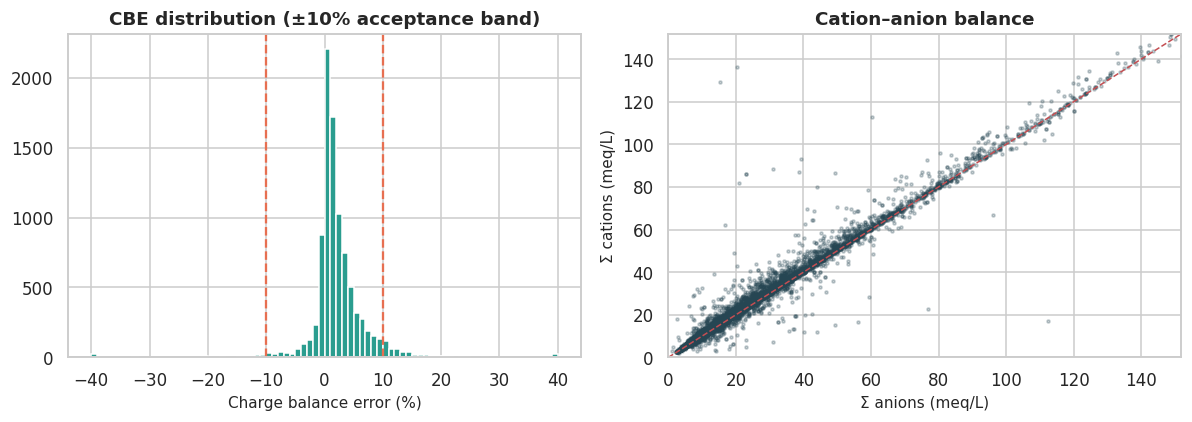

In [13]:
EQW = {"Ca": 20.04, "Mg": 12.15, "Na": 22.99, "K": 39.10,          # cations
       "Cl": 35.45, "SO4": 48.03, "HCO3": 61.02, "CO3": 30.00, "NO3": 62.00}  # anions

def to_meq(frame):
    meq = pd.DataFrame(index=frame.index)
    for ion, w in EQW.items():
        if ion in frame.columns:
            meq[ion] = frame[ion].fillna(0.0) / w
    return meq

meq = to_meq(df)
df["cations_meq"] = meq[[c for c in ["Ca", "Mg", "Na", "K"] if c in meq]].sum(axis=1)
df["anions_meq"]  = meq[[c for c in ["Cl", "SO4", "HCO3", "CO3"] if c in meq]].sum(axis=1)
df["CBE"] = 100 * (df["cations_meq"] - df["anions_meq"]) / (df["cations_meq"] + df["anions_meq"])

print(f"|CBE| <=  5% : {(df['CBE'].abs() <= 5).mean():.1%}")
print(f"|CBE| <= 10% : {(df['CBE'].abs() <= 10).mean():.1%}")
print(f"|CBE| <= 15% : {(df['CBE'].abs() <= 15).mean():.1%}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(df["CBE"].clip(-40, 40), bins=80, color="#2a9d8f", edgecolor="white")
for v in (-10, 10): ax[0].axvline(v, color="#e76f51", ls="--")
ax[0].set_xlabel("Charge balance error (%)"); ax[0].set_title("CBE distribution (±10% acceptance band)")
ax[1].scatter(df["anions_meq"], df["cations_meq"], s=4, alpha=.25, color="#264653")
lim = [0, np.nanpercentile(df["cations_meq"], 99.5)]
ax[1].plot(lim, lim, "r--", lw=1); ax[1].set_xlim(lim); ax[1].set_ylim(lim)
ax[1].set_xlabel("Σ anions (meq/L)"); ax[1].set_ylabel("Σ cations (meq/L)"); ax[1].set_title("Cation–anion balance")
savefig("03_charge_balance")
plt.show()

In [14]:
CBE_TOL = 10.0
n0 = len(df)
df = df[df["CBE"].abs() <= CBE_TOL].reset_index(drop=True)
print(f"Analytically validated dataset: {len(df):,} samples "
      f"({n0 - len(df):,} rejected, {(n0-len(df))/n0:.1%}) · {df['Station'].nunique():,} stations")

Analytically validated dataset: 8,812 samples (596 rejected, 6.3%) · 1,417 stations


## 5 · Hydrochemical feature engineering


In [15]:
meq = to_meq(df)
eps = 1e-9

# --- classical irrigation-suitability indices -----------------------------------
# Sodium Adsorption Ratio — sodicity / soil-structure hazard (Richards 1954)
df["SAR"] = meq["Na"] / np.sqrt((meq["Ca"] + meq["Mg"]) / 2 + eps)

# Soluble Sodium Percentage (%Na) — Wilcox
df["Na_pct"] = 100 * meq["Na"] / (meq["Ca"] + meq["Mg"] + meq["Na"] + eps)

# Residual Sodium Carbonate — alkalinity hazard (Eaton 1950)
df["RSC"] = (meq["HCO3"] + meq["CO3"]) - (meq["Ca"] + meq["Mg"])

# Kelly's Ratio — >1 indicates sodium excess
df["KR"] = meq["Na"] / (meq["Ca"] + meq["Mg"] + eps)

# Magnesium Hazard (Szabolcs & Darab 1964) — >50 harms soil
df["MH"] = 100 * meq["Mg"] / (meq["Ca"] + meq["Mg"] + eps)

# Permeability Index (Doneen)
df["PI"] = 100 * (meq["Na"] + np.sqrt(meq["HCO3"] + eps)) / (meq["Ca"] + meq["Mg"] + meq["Na"] + eps)

# Corrosivity Ratio — pipe-corrosion potential
df["CR"] = ((meq["Cl"]) + 2 * (meq["SO4"])) / (2 * (meq["HCO3"] + meq["CO3"]) + eps)

# --- geochemical process signatures ---------------------------------------------
df["Na_Cl_ratio"]  = meq["Na"] / (meq["Cl"] + eps)
df["Ca_Mg_ratio"]  = meq["Ca"] / (meq["Mg"] + eps)
df["Cl_HCO3_ratio"]= meq["Cl"] / (meq["HCO3"] + eps)
df["SO4_Cl_ratio"] = meq["SO4"] / (meq["Cl"] + eps)
df["base_exchange"]= (meq["Na"] - meq["Cl"]) / (meq["Ca"] + meq["Mg"] + meq["Na"] + eps)
df["ionic_strength"] = 0.5 * (meq["Ca"]*4 + meq["Mg"]*4 + meq["Na"] + meq["Cl"] +
                              meq["SO4"]*4 + meq["HCO3"]) / 1000
df["hardness_type"] = np.where(df["TH"] > df["ALK"], 1, 0)

# --- field-measurable transforms -------------------------------------------------
df["logEC"]  = np.log10(df["EC"])
df["pH_dev"] = df["pH"] - 7.0
df["EC_x_pH"]= df["logEC"] * df["pH"]
df["EC_est_TDS"] = 0.65 * df["EC"]
# --- spatial encodings -----------------------------------------------------------
lat_r, lon_r = np.radians(df["Latitude"]), np.radians(df["Longitude"])
df["geo_x"] = np.cos(lat_r) * np.cos(lon_r)
df["geo_y"] = np.cos(lat_r) * np.sin(lon_r)
df["geo_z"] = np.sin(lat_r)

df["aravalli_dist"] = np.abs(1.12 * df["Latitude"] - df["Longitude"] + 45.17) / np.sqrt(1.12**2 + 1)

ENGINEERED = ["SAR", "Na_pct", "RSC", "KR", "MH", "PI", "CR", "Na_Cl_ratio", "Ca_Mg_ratio",
              "Cl_HCO3_ratio", "SO4_Cl_ratio", "base_exchange", "ionic_strength", "hardness_type"]
display(df[ENGINEERED].describe(percentiles=[.05, .5, .95]).T.round(3))

,count,mean,std,min,5%,50%,95%,max
SAR,8812.0,8.175,7.947,0.077,0.740,5.479,24.051,74.487
Na_pct,8812.0,56.178,22.230,1.697,17.873,57.965,88.314,97.813
RSC,8812.0,-1.772,8.762,-117.409,-17.692,-0.399,8.932,26.956
KR,8812.0,2.357,2.885,0.017,0.218,1.379,7.557,44.725
MH,8812.0,54.688,17.722,0.954,24.133,56.195,82.201,98.187
PI,8812.0,72.721,18.376,7.222,41.724,73.233,101.564,130.669
CR,8812.0,1.976,3.851,0.032,0.176,0.852,7.146,119.020
Na_Cl_ratio,8812.0,1.871,1.798,0.045,0.604,1.425,4.476,44.546
Ca_Mg_ratio,8812.0,1.240,2.386,0.018,0.217,0.780,3.144,103.796
Cl_HCO3_ratio,8812.0,2.480,6.358,0.021,0.165,0.920,9.381,210.500


## 6 · Target construction

### 6.1 Water Quality Index (drinking water)
.

Standards $S_i$ are **BIS 10500:2012** acceptable limits. Sub-index and index:

$$q_i = 100\,\frac{C_i}{S_i}, \qquad W_i = \frac{w_i}{\sum w_i}, \qquad \mathrm{WQI} = \sum_i W_i\,q_i$$

**TDS / EC is deliberately excluded from the index** (Finding 3) so that EC stays a clean *predictor* and never
leaks into the *label*.

In [16]:
BIS_STANDARD = {"pH": 8.5, "TH": 200, "Cl": 250, "SO4": 200, "ALK": 200,
                "Ca": 75, "Mg": 30, "Fe": 0.3, "Na": 200}
ASSIGNED_W   = {"pH": 4,   "TH": 2,   "Cl": 3,   "SO4": 4,   "ALK": 1,
                "Ca": 2,   "Mg": 2,   "Fe": 4,   "Na": 3}

wsum = sum(ASSIGNED_W.values())
W = {k: v / wsum for k, v in ASSIGNED_W.items()}
wqi_tbl = pd.DataFrame({"BIS_limit": BIS_STANDARD, "assigned_w": ASSIGNED_W,
                        "relative_W": pd.Series(W).round(4)})
display(wqi_tbl)

q = pd.DataFrame({p: 100 * df[p] / s for p, s in BIS_STANDARD.items()})
df["WQI"] = sum(q[p] * W[p] for p in BIS_STANDARD)

WQI_BINS   = [-np.inf, 50, 100, 200, 300, np.inf]
WQI_LABELS = ["Excellent", "Good", "Poor", "Very Poor", "Unfit"]
df["WQI_class"] = pd.cut(df["WQI"], WQI_BINS, labels=WQI_LABELS)

print(df["WQI"].describe(percentiles=[.05, .25, .5, .75, .95]).round(1).to_string())
print()
cls_tbl = df["WQI_class"].value_counts().reindex(WQI_LABELS).to_frame("n")
cls_tbl["share"] = (cls_tbl["n"] / len(df) * 100).round(1)
display(cls_tbl)

,BIS_limit,assigned_w,relative_W
pH,8.5,4,0.16
TH,200.0,2,0.08
Cl,250.0,3,0.12
SO4,200.0,4,0.16
ALK,200.0,1,0.04
Ca,75.0,2,0.08
Mg,30.0,2,0.08
Fe,0.3,4,0.16
Na,200.0,3,0.12


count    8812.0
mean      169.6
std       140.4
min        29.1
5%         53.8
25%        83.1
50%       125.4
75%       202.7
95%       447.7
max      2107.1



,n,share
WQI_class,,
Excellent,306,3.5
Good,2886,32.8
Poor,3369,38.2
Very Poor,1197,13.6
Unfit,1054,12.0


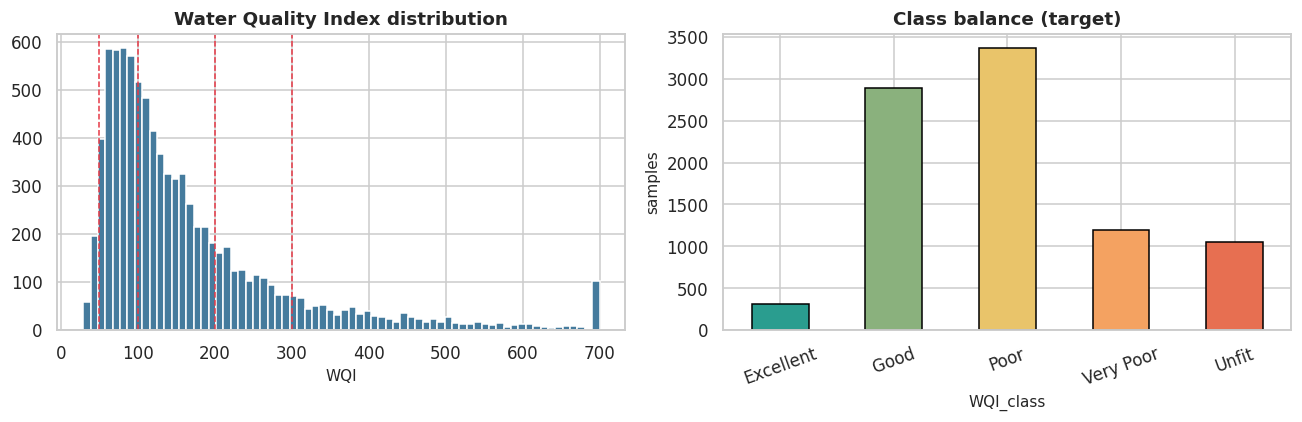

Imbalance ratio (majority : minority) = 11.0 : 1  ->  macro-F1 is the headline metric, not accuracy.


In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df["WQI"].clip(0, 700), bins=70, color="#457b9d", edgecolor="white")
for b in WQI_BINS[1:-1]: ax[0].axvline(b, color="#e63946", ls="--", lw=1)
ax[0].set_xlabel("WQI"); ax[0].set_title("Water Quality Index distribution")
cls_tbl["n"].plot(kind="bar", ax=ax[1], color=PALETTE, edgecolor="black")
ax[1].set_title("Class balance (target)"); ax[1].set_ylabel("samples"); ax[1].tick_params(axis="x", rotation=20)
savefig("04_target")
plt.show()

IMBALANCE = cls_tbl["n"].max() / cls_tbl["n"].min()
print(f"Imbalance ratio (majority : minority) = {IMBALANCE:.1f} : 1  ->  macro-F1 is the headline metric, not accuracy.")

### 6.2 Secondary target — irrigation sodicity (SAR)


USSL
C3-S1    3764
C2-S1    1256
C4-S2    1217
C4-S1    1097
C4-S3     609
C3-S2     449
C4-S4     338
C3-S3      54
C1-S1      13
C3-S4       9


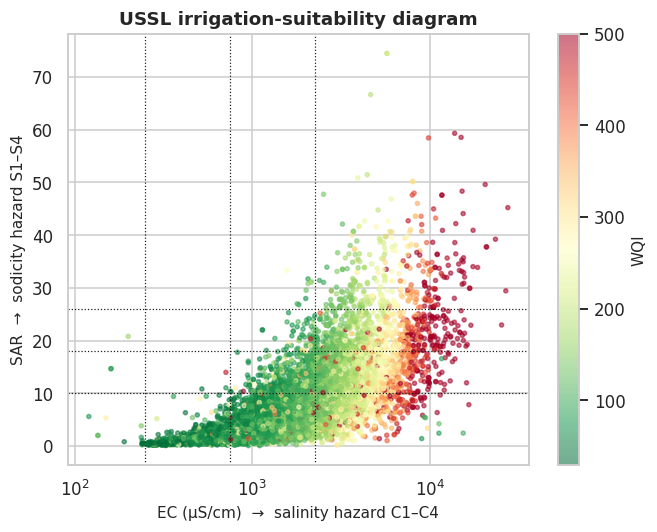

In [18]:
def ussl_class(ec, sar):
    s = np.select([sar < 10, sar < 18, sar < 26], ["S1", "S2", "S3"], "S4")
    c = np.select([ec < 250, ec < 750, ec < 2250], ["C1", "C2", "C3"], "C4")
    return pd.Series([f"{a}-{b}" for a, b in zip(c, s)], index=ec.index)

df["USSL"] = ussl_class(df["EC"], df["SAR"])
print(df["USSL"].value_counts().head(10).to_string())

plt.figure(figsize=(6.2, 5))
sc = plt.scatter(df["EC"], df["SAR"], c=df["WQI"].clip(0, 500), cmap="RdYlGn_r", s=7, alpha=.55)
plt.xscale("log"); plt.colorbar(sc, label="WQI")
for v in (250, 750, 2250): plt.axvline(v, color="k", ls=":", lw=.8)
for h in (10, 18, 26):      plt.axhline(h, color="k", ls=":", lw=.8)
plt.xlabel("EC (µS/cm)  →  salinity hazard C1–C4")
plt.ylabel("SAR  →  sodicity hazard S1–S4")
plt.title("USSL irrigation-suitability diagram")
savefig("05_ussl")
plt.show()

## 7 · Exploratory data analysis

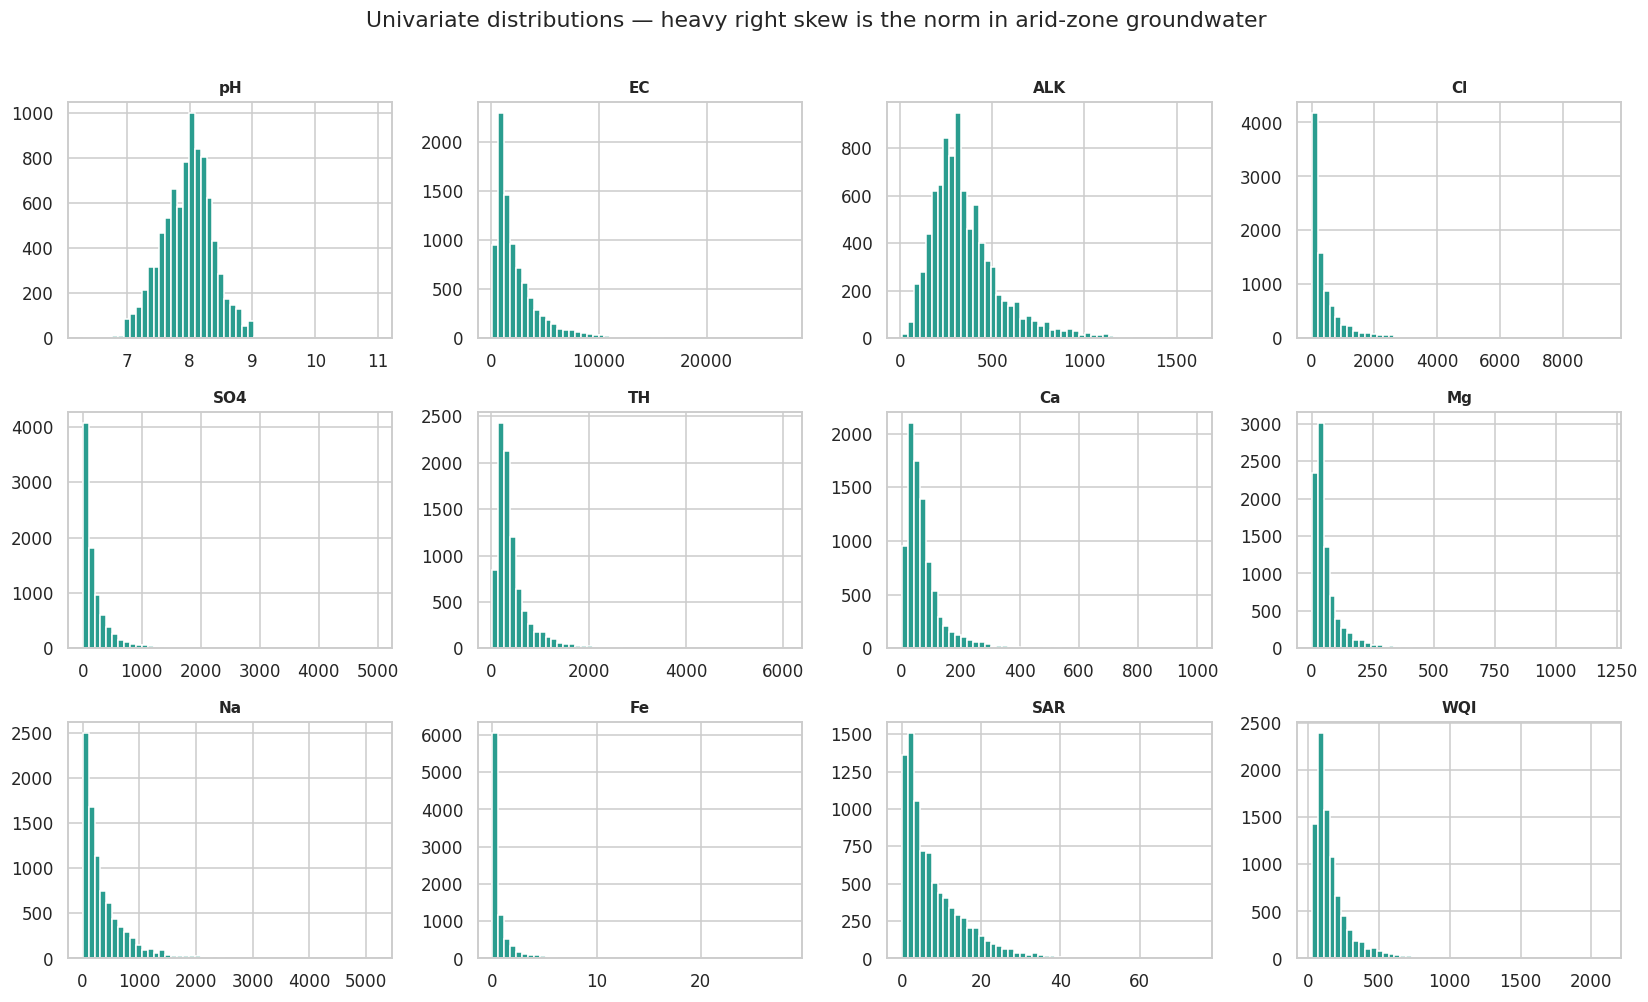

In [19]:
PARAMS = ["pH", "EC", "ALK", "Cl", "SO4", "TH", "Ca", "Mg", "Na", "Fe", "SAR", "WQI"]
fig, axes = plt.subplots(3, 4, figsize=(15, 9))
for ax, p in zip(axes.ravel(), PARAMS):
    v = df[p].dropna()
    logscale = v.min() > 0 and (v.max() / max(v.median(), 1e-6)) > 50
    ax.hist(np.log10(v) if logscale else v, bins=50, color="#2a9d8f", edgecolor="white")
    ax.set_title(f"log10({p})" if logscale else p, fontsize=10)
plt.suptitle("Univariate distributions — heavy right skew is the norm in arid-zone groundwater", y=1.01)
savefig("06_distributions")
plt.show()

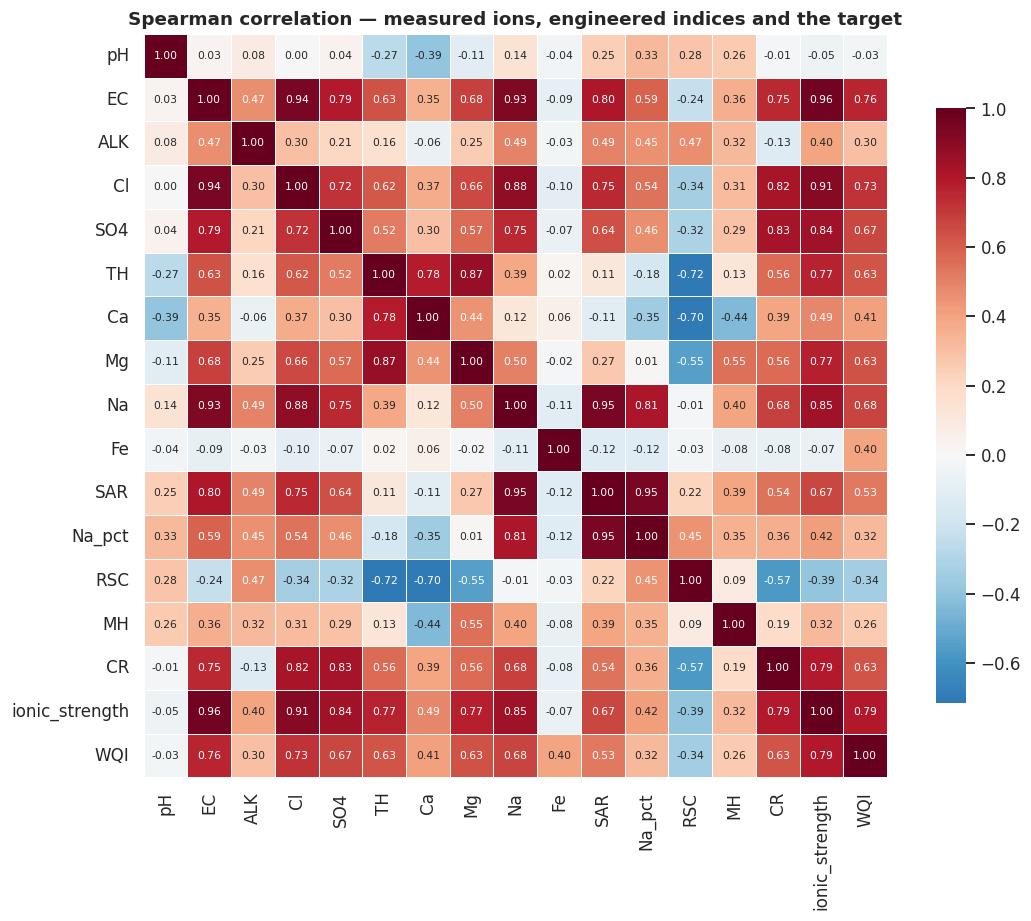

Strongest Spearman correlations with WQI:
ionic_strength    0.793
EC                0.765
Cl                0.725
Na                0.678
SO4               0.666
Mg                0.634
TH                0.629
CR                0.629


In [20]:
CORR_COLS = ["pH", "EC", "ALK", "Cl", "SO4", "TH", "Ca", "Mg", "Na", "Fe",
             "SAR", "Na_pct", "RSC", "MH", "CR", "ionic_strength", "WQI"]
corr = df[CORR_COLS].corr(method="spearman")
plt.figure(figsize=(10.5, 8.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=.4, annot_kws={"size": 7}, cbar_kws={"shrink": .8})
plt.title("Spearman correlation — measured ions, engineered indices and the target")
savefig("07_correlation")
plt.show()

print("Strongest Spearman correlations with WQI:")
print(corr["WQI"].drop("WQI").abs().sort_values(ascending=False).head(8).round(3).to_string())

Theil–Sen trend in median WQI : -0.89 index-units / year  (95% CI -1.95 .. +0.13)
Mann–Kendall                   : Z = -1.74, p = 0.0814 -> not significant at alpha = 0.05


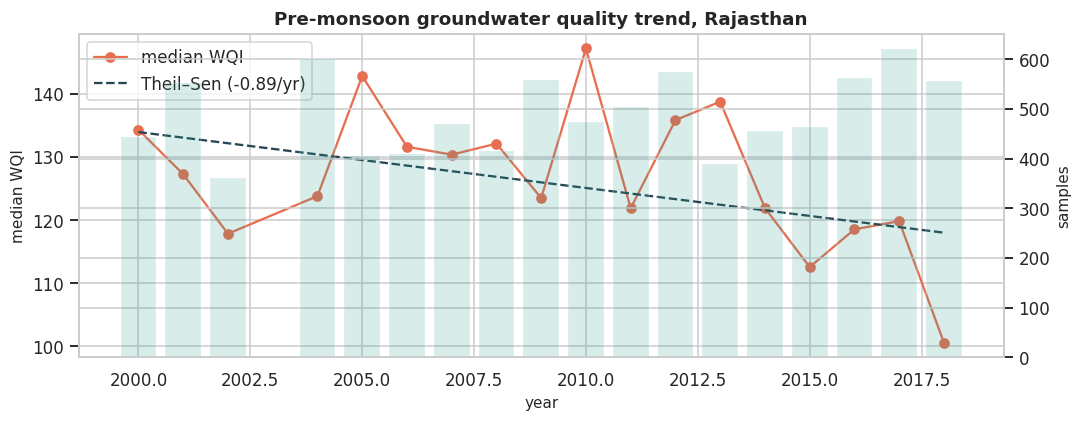

In [21]:
# Temporal trend with a non-parametric Theil–Sen slope and Mann–Kendall test
yearly = df.groupby("year").agg(WQI_median=("WQI", "median"), EC_median=("EC", "median"),
                                n=("WQI", "size")).reset_index()

def mann_kendall(x):
    x = np.asarray(x, float); n = len(x)
    s = sum(np.sign(x[j] - x[i]) for i in range(n - 1) for j in range(i + 1, n))
    var = n * (n - 1) * (2 * n + 5) / 18
    z = (s - np.sign(s)) / np.sqrt(var) if s != 0 else 0.0
    return s, z, 2 * (1 - stats.norm.cdf(abs(z)))

yy = yearly[yearly["n"] > 50]
slope, icept, lo, hi = stats.theilslopes(yy["WQI_median"], yy["year"], 0.95)
S, Z, pval = mann_kendall(yy["WQI_median"].values)
print(f"Theil–Sen trend in median WQI : {slope:+.2f} index-units / year  (95% CI {lo:+.2f} .. {hi:+.2f})")
print(f"Mann–Kendall                   : Z = {Z:.2f}, p = {pval:.4f} "
      f"-> {'significant' if pval < 0.05 else 'not significant'} at alpha = 0.05")

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(yy["year"], yy["WQI_median"], "o-", color="#e76f51", label="median WQI")
ax1.plot(yy["year"], icept + slope * yy["year"], "--", color="#264653",
         label=f"Theil–Sen ({slope:+.2f}/yr)")
ax1.set_ylabel("median WQI"); ax1.set_xlabel("year"); ax1.legend(loc="upper left")
ax2 = ax1.twinx(); ax2.bar(yy["year"], yy["n"], alpha=.18, color="#2a9d8f"); ax2.set_ylabel("samples")
plt.title("Pre-monsoon groundwater quality trend, Rajasthan")
savefig("08_trend")
plt.show()

,n,median_WQI,pct_unsafe,median_EC,median_SAR
District,,,,,
CHURU,269,194.5,48.7,3640.0,14.7
BHARATPUR,374,187.9,45.5,3060.0,7.7
JALORE,112,189.7,43.8,3325.0,11.9
NAGAUR,269,173.1,42.4,3510.0,14.0
BARMER,442,168.9,40.7,3290.0,12.3
AJMER,379,135.6,35.1,1910.0,7.1
GANGANAGAR,318,129.7,32.1,1487.5,4.1
PALI,297,137.9,32.0,2580.0,8.6
HANUMANGARH,188,134.0,29.3,1675.0,4.3


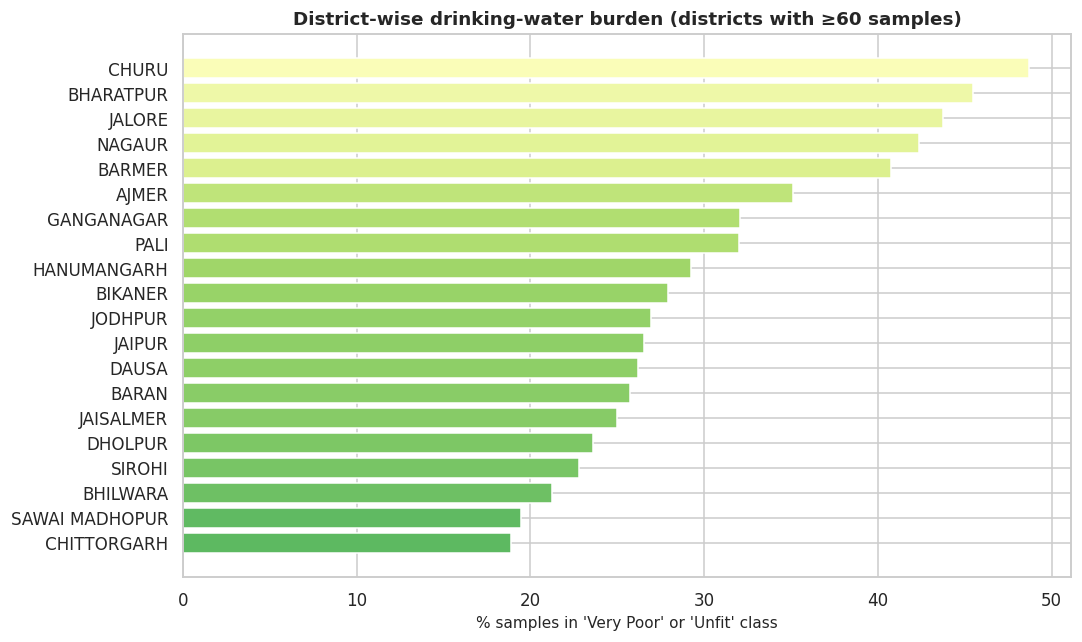

In [22]:
# District-level burden
dist = (df.groupby("District")
          .agg(n=("WQI", "size"), median_WQI=("WQI", "median"),
               pct_unsafe=("WQI_class", lambda s: 100 * s.isin(["Very Poor", "Unfit"]).mean()),
               median_EC=("EC", "median"), median_SAR=("SAR", "median"))
          .query("n >= 60").sort_values("pct_unsafe", ascending=False))
display(dist.head(12).round(1))
dist.round(2).to_csv(OUT / "tables" / "district_summary.csv")

plt.figure(figsize=(10, 6))
top = dist.head(20)
plt.barh(top.index[::-1], top["pct_unsafe"][::-1],
         color=plt.cm.RdYlGn_r(top["pct_unsafe"][::-1] / 100))
plt.xlabel("% samples in 'Very Poor' or 'Unfit' class")
plt.title("District-wise drinking-water burden (districts with ≥60 samples)")
savefig("09_districts")
plt.show()

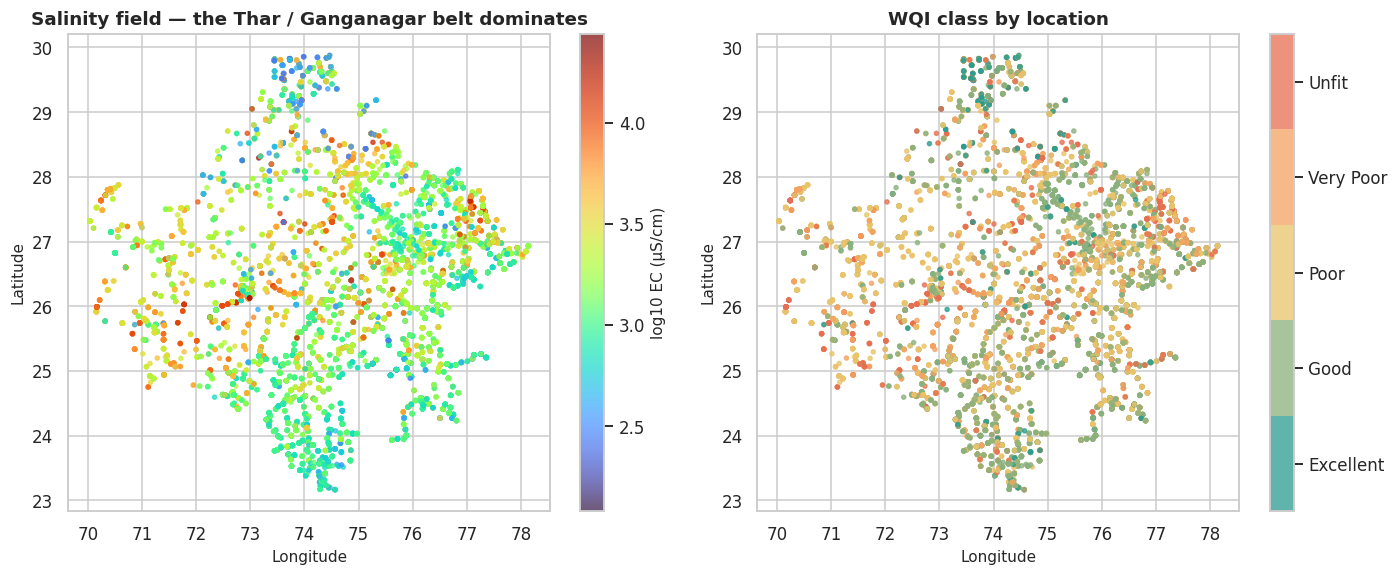

In [23]:
# Spatial view
fig, ax = plt.subplots(1, 2, figsize=(13, 5.4))
s0 = ax[0].scatter(df["Longitude"], df["Latitude"], c=np.log10(df["EC"]),
                   cmap="turbo", s=7, alpha=.7)
plt.colorbar(s0, ax=ax[0], label="log10 EC (µS/cm)")
ax[0].set_title("Salinity field — the Thar / Ganganagar belt dominates")

codes = {c: i for i, c in enumerate(WQI_LABELS)}
s1 = ax[1].scatter(df["Longitude"], df["Latitude"],
                   c=df["WQI_class"].map(codes), cmap=mpl.colors.ListedColormap(PALETTE),
                   s=7, alpha=.75, vmin=-.5, vmax=4.5)
cb = plt.colorbar(s1, ax=ax[1], ticks=range(5)); cb.ax.set_yticklabels(WQI_LABELS)
ax[1].set_title("WQI class by location")
for a in ax: a.set_xlabel("Longitude"); a.set_ylabel("Latitude")
savefig("10_spatial")
plt.show()

In [24]:
from sklearn.model_selection import (StratifiedGroupKFold, GroupKFold, RandomizedSearchCV,
                                     cross_val_predict, train_test_split)
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              HistGradientBoostingClassifier, HistGradientBoostingRegressor,
                              StackingClassifier, VotingClassifier, GradientBoostingRegressor)
from sklearn.linear_model import LogisticRegression, QuantileRegressor
from sklearn.neighbors import BallTree, KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score, cohen_kappa_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, r2_score, mean_absolute_error, mean_squared_error)
import joblib

# The nine parameters that build the label — banned as predictors
BANNED = ["TH", "Cl", "SO4", "ALK", "Ca", "Mg", "Na", "Fe", "WQI",
          "CO3", "HCO3", "cations_meq", "anions_meq", "CBE", "USSL"]
print("Banned from X (label constituents / derivatives):")
print(textwrap.fill(", ".join(BANNED), 110))

Banned from X (label constituents / derivatives):
TH, Cl, SO4, ALK, Ca, Mg, Na, Fe, WQI, CO3, HCO3, cations_meq, anions_meq, CBE, USSL


In [25]:
EARTH_R_KM = 6371.0
KNN_COLS = ["nn_wqi_idw", "nn_wqi_mean", "nn_wqi_std", "nn_ec_idw", "nn_resid_idw", "nn_dist_km"]

def spatial_knn_features(data, fit_idx, apply_idx, k=20, oversample=40):
    """Inverse-distance-weighted neighbourhood features, built ONLY from `fit_idx` rows."""
    XY = np.radians(data[["Latitude", "Longitude"]].to_numpy())
    tree = BallTree(XY[fit_idx], metric="haversine")
    K = min(k + oversample, len(fit_idx))
    dist, ind = tree.query(XY[apply_idx], k=K)

    st_fit = data["Station"].to_numpy()[fit_idx]
    st_app = data["Station"].to_numpy()[apply_idx]
    tgt    = np.log10(data["WQI"].to_numpy()[fit_idx])
    ecv    = data["logEC"].to_numpy()[fit_idx]

    out = np.full((len(apply_idx), len(KNN_COLS)), np.nan)
    for i in range(len(apply_idx)):
        keep = np.where(st_fit[ind[i]] != st_app[i])[0][:k]     # drop self-station neighbours
        if keep.size == 0:
            continue
        d_km = dist[i, keep] * EARTH_R_KM
        w = 1.0 / (d_km + 1e-3)
        t, e = tgt[ind[i, keep]], ecv[ind[i, keep]]
        out[i] = [np.average(t, weights=w), t.mean(), t.std(),
                  np.average(e, weights=w), np.average(t - e, weights=w), d_km.mean()]
    return pd.DataFrame(out, columns=KNN_COLS, index=data.index[apply_idx])

In [26]:
df = df.sort_values(["Station", "date"]).reset_index(drop=True)
df["logWQI"] = np.log10(df["WQI"])

g = df.groupby("Station", sort=False)
HIST_COLS = []
for c in ["logWQI", "logEC", "pH", "SAR"]:
    df[f"prev_{c}"]  = g[c].shift(1)
    df[f"pmean_{c}"] = g[c].transform(lambda s: s.shift(1).expanding().mean())
    df[f"pmax_{c}"]  = g[c].transform(lambda s: s.shift(1).expanding().max())
    HIST_COLS += [f"prev_{c}", f"pmean_{c}", f"pmax_{c}"]
df["prev_gap_yr"] = g["year"].diff()
df["n_prior"]     = g.cumcount()
df["ec_delta"]    = df["logEC"] - df["prev_logEC"]
HIST_COLS += ["prev_gap_yr", "n_prior", "ec_delta"]

print(f"{len(HIST_COLS)} history features created")
print(f"Rows with at least one prior visit: {(df['n_prior'] > 0).mean():.1%}")

15 history features created
Rows with at least one prior visit: 83.9%


In [27]:
# ---- feature blocks -------------------------------------------------------------
GEO_F   = ["Latitude", "Longitude", "geo_x", "geo_y", "geo_z", "aravalli_dist", "year"]
FIELD_F = ["pH", "logEC", "pH_dev", "EC_x_pH", "EC_est_TDS"]
FEATURE_SETS = {
    "A · geography only":            GEO_F,
    "B · geography + spatial k-NN":  GEO_F + KNN_COLS,
    "C · + field kit (pH, EC)":      GEO_F + KNN_COLS + FIELD_F,
}
y      = df["WQI_class"].astype(str).to_numpy()
groups = df["Station"].to_numpy()
for name, cols in FEATURE_SETS.items():
    assert not set(cols) & set(BANNED), f"LEAKAGE in {name}"
print("Leakage assertion passed for every feature set.\n")
for n, c in FEATURE_SETS.items():
    print(f"{n:32s} -> {len(c):2d} features")

Leakage assertion passed for every feature set.

A · geography only               ->  7 features
B · geography + spatial k-NN     -> 13 features
C · + field kit (pH, EC)         -> 18 features


In [28]:
cv_S = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SPLITS_S = list(cv_S.split(df, y, groups=groups))

def run_protocol_S(model_factory, feature_cols, needs_knn=True, tag=""):
    """Manual grouped CV so the k-NN encoder can be refit inside every fold."""
    oof = np.empty(len(df), dtype=object)
    oof_proba, classes_ref = None, None
    for tr, te in SPLITS_S:
        D = df.copy()
        if needs_knn:
            D.loc[D.index[tr], KNN_COLS] = spatial_knn_features(df, tr, tr).to_numpy()
            D.loc[D.index[te], KNN_COLS] = spatial_knn_features(df, tr, te).to_numpy()
        Xtr = D.iloc[tr][feature_cols].astype(float)
        Xte = D.iloc[te][feature_cols].astype(float)
        m = model_factory()
        m.fit(Xtr, y[tr])
        oof[te] = m.predict(Xte)
        if hasattr(m, "predict_proba"):
            if oof_proba is None:
                classes_ref = m.classes_
                oof_proba = np.zeros((len(df), len(classes_ref)))
            oof_proba[te] = m.predict_proba(Xte)[:, [list(m.classes_).index(c) for c in classes_ref]]
    res = {"model": tag,
           "accuracy": accuracy_score(y, oof),
           "balanced_acc": balanced_accuracy_score(y, oof),
           "macro_F1": f1_score(y, oof, average="macro"),
           "weighted_F1": f1_score(y, oof, average="weighted"),
           "kappa": cohen_kappa_score(y, oof)}
    if oof_proba is not None:
        res["ROC_AUC_ovr"] = roc_auc_score(pd.get_dummies(y)[classes_ref], oof_proba,
                                           average="macro", multi_class="ovr")
    return res, oof, oof_proba, classes_ref

def hgb(**kw):
    p = dict(max_iter=300, learning_rate=0.08, max_leaf_nodes=31, min_samples_leaf=20,
             l2_regularization=1.0, random_state=RANDOM_STATE)
    p.update(kw)
    return HistGradientBoostingClassifier(**p)

ablation = []
for name, cols in FEATURE_SETS.items():
    r, _, _, _ = run_protocol_S(hgb, cols, needs_knn=True, tag=name)
    ablation.append(r)
    print(f"{name:32s}  acc={r['accuracy']:.4f}  macroF1={r['macro_F1']:.4f}  AUC={r.get('ROC_AUC_ovr', np.nan):.4f}")

abl = pd.DataFrame(ablation).set_index("model").round(4)
display(abl)
abl.to_csv(OUT / "tables" / "ablation_protocolS.csv")

A · geography only                acc=0.4026  macroF1=0.2840  AUC=0.6145
B · geography + spatial k-NN      acc=0.4041  macroF1=0.2645  AUC=0.6089
C · + field kit (pH, EC)          acc=0.6672  macroF1=0.6035  AUC=0.8679


,accuracy,balanced_acc,macro_F1,weighted_F1,kappa,ROC_AUC_ovr
model,,,,,,
A · geography only,0.4026,0.2783,0.2840,0.3804,0.1183,0.6145
B · geography + spatial k-NN,0.4041,0.2646,0.2645,0.3709,0.1065,0.6089
"C · + field kit (pH, EC)",0.6672,0.5744,0.6035,0.6616,0.5207,0.8679


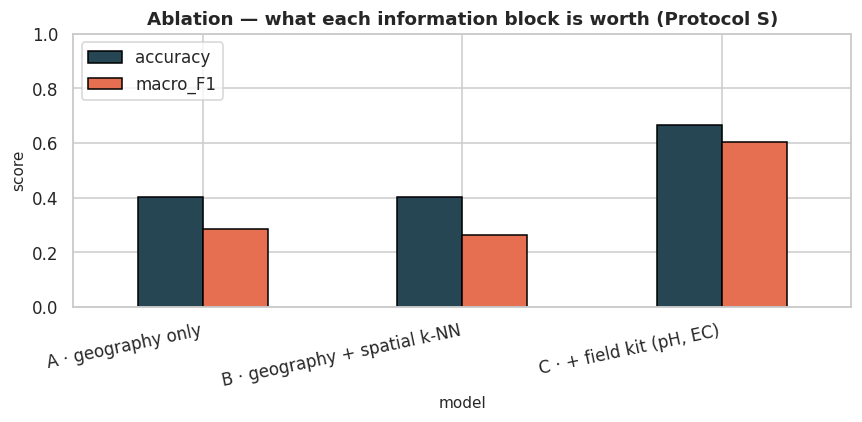

macro-F1 lift from adding a ₹2,000 field meter: +0.320


In [29]:
plt.figure(figsize=(8, 4))
abl[["accuracy", "macro_F1"]].plot(kind="bar", ax=plt.gca(), color=["#264653", "#e76f51"], edgecolor="black")
plt.xticks(rotation=12, ha="right"); plt.ylabel("score"); plt.ylim(0, 1)
plt.title("Ablation — what each information block is worth (Protocol S)")
plt.legend(loc="upper left")
savefig("11_ablation")
plt.show()

lift = abl.loc["C · + field kit (pH, EC)", "macro_F1"] - abl.loc["A · geography only", "macro_F1"]
print(f"macro-F1 lift from adding a ₹2,000 field meter: +{lift:.3f}")

In [30]:
BEST_FEATURES = FEATURE_SETS["C · + field kit (pH, EC)"]

def make_logreg():
    return Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("sc", StandardScaler()),
                     ("clf", LogisticRegression(max_iter=3000, C=1.0,
                                                class_weight="balanced"))])

def make_knn():
    return Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("sc", StandardScaler()),
                     ("clf", KNeighborsClassifier(n_neighbors=25, weights="distance"))])

def make_rf():
    return Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("clf", RandomForestClassifier(n_estimators=300, min_samples_leaf=1,
                                                    max_features="sqrt", class_weight="balanced_subsample",
                                                    n_jobs=-1, random_state=RANDOM_STATE))])

def make_et():
    return Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("clf", ExtraTreesClassifier(n_estimators=300, min_samples_leaf=1,
                                                  max_features="sqrt", class_weight="balanced_subsample",
                                                  n_jobs=-1, random_state=RANDOM_STATE))])

def make_hgb():
    return hgb(max_iter=400, learning_rate=0.06, max_leaf_nodes=63, min_samples_leaf=15)

def make_boost():
    """XGBoost / LightGBM when installed, otherwise scikit-learn's HistGradientBoosting."""
    if HAS["lightgbm"]:
        from lightgbm import LGBMClassifier
        return LGBMClassifier(n_estimators=600, learning_rate=0.05, num_leaves=63,
                              subsample=0.85, subsample_freq=1, colsample_bytree=0.85,
                              reg_lambda=1.0, class_weight="balanced",
                              random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    if HAS["xgboost"]:
        from xgboost import XGBClassifier
        from sklearn.preprocessing import LabelEncoder
        return Pipeline([("imp", SimpleImputer(strategy="median")),
                         ("clf", XGBClassifier(n_estimators=600, learning_rate=0.05, max_depth=7,
                                               subsample=0.85, colsample_bytree=0.85, reg_lambda=1.0,
                                               tree_method="hist", random_state=RANDOM_STATE,
                                               n_jobs=-1, eval_metric="mlogloss"))])
    return make_hgb()

def make_voting():
    return Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("clf", VotingClassifier(
                         estimators=[
                             ("rf",  RandomForestClassifier(250, min_samples_leaf=1, max_features="sqrt",
                                                            n_jobs=-1, random_state=RANDOM_STATE)),
                             ("et",  ExtraTreesClassifier(250, min_samples_leaf=1, max_features="sqrt",
                                                          n_jobs=-1, random_state=RANDOM_STATE)),
                             ("hgb", hgb(max_iter=250, max_leaf_nodes=63)),
                         ], voting="soft", n_jobs=1))])

ZOO = {
    "Logistic Regression (baseline)": make_logreg,
    "k-NN (k=25)":                    make_knn,
    "Random Forest":                  make_rf,
    "Extra Trees":                    make_et,
    "HistGradientBoosting":           make_hgb,
    "Boosted (LGBM/XGB/HGB)":         make_boost,
    "Soft-Voting ensemble":           make_voting,
}

zoo_rows, oof_store = [], {}
for name, fac in ZOO.items():
    r, oof, proba, cls = run_protocol_S(fac, BEST_FEATURES, needs_knn=True, tag=name)
    zoo_rows.append(r); oof_store[name] = (oof, proba, cls)
    print(f"{name:32s} acc={r['accuracy']:.4f}  bal_acc={r['balanced_acc']:.4f}  "
          f"macroF1={r['macro_F1']:.4f}  kappa={r['kappa']:.4f}")

zoo = pd.DataFrame(zoo_rows).set_index("model").sort_values("macro_F1", ascending=False).round(4)
display(zoo)
zoo.to_csv(OUT / "tables" / "model_zoo_protocolS.csv")

Logistic Regression (baseline)   acc=0.6333  bal_acc=0.6631  macroF1=0.6052  kappa=0.4971
k-NN (k=25)                      acc=0.6189  bal_acc=0.4876  macroF1=0.5277  kappa=0.4374
Random Forest                    acc=0.6792  bal_acc=0.5846  macroF1=0.6173  kappa=0.5376
Extra Trees                      acc=0.6766  bal_acc=0.5743  macroF1=0.6101  kappa=0.5321
HistGradientBoosting             acc=0.6684  bal_acc=0.5716  macroF1=0.6007  kappa=0.5224
Boosted (LGBM/XGB/HGB)           acc=0.6656  bal_acc=0.5947  macroF1=0.6141  kappa=0.5219
Soft-Voting ensemble             acc=0.6761  bal_acc=0.5794  macroF1=0.6108  kappa=0.5332


,accuracy,balanced_acc,macro_F1,weighted_F1,kappa,ROC_AUC_ovr
model,,,,,,
Random Forest,0.6792,0.5846,0.6173,0.6732,0.5376,0.8728
Boosted (LGBM/XGB/HGB),0.6656,0.5947,0.6141,0.6623,0.5219,0.8650
Soft-Voting ensemble,0.6761,0.5794,0.6108,0.6701,0.5332,0.8744
Extra Trees,0.6766,0.5743,0.6101,0.6691,0.5321,0.8720
Logistic Regression (baseline),0.6333,0.6631,0.6052,0.6398,0.4971,0.8686
HistGradientBoosting,0.6684,0.5716,0.6007,0.6625,0.5224,0.8672
k-NN (k=25),0.6189,0.4876,0.5277,0.6022,0.4374,0.8288


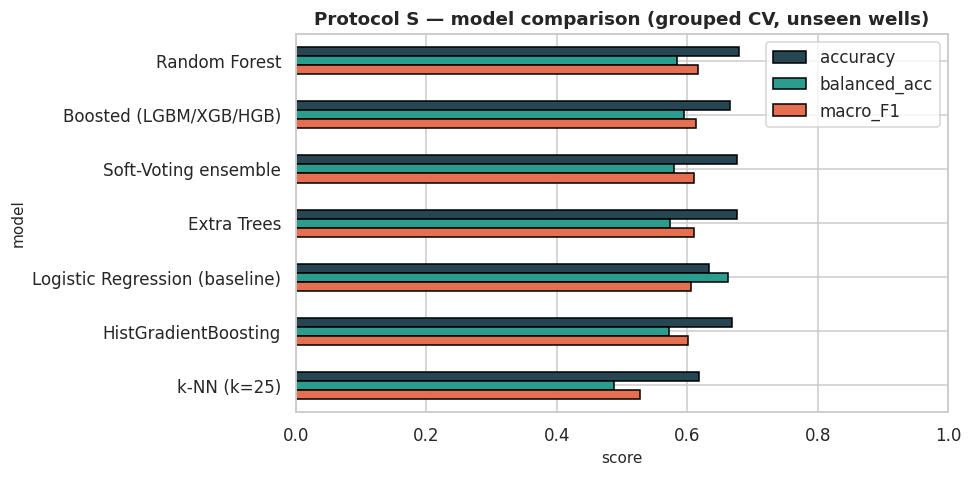

Best model on macro-F1: Random Forest


In [31]:
fig, ax = plt.subplots(figsize=(9, 4.5))
zoo[["accuracy", "balanced_acc", "macro_F1"]].plot(kind="barh", ax=ax,
                                                   color=["#264653", "#2a9d8f", "#e76f51"], edgecolor="black")
ax.set_xlim(0, 1); ax.set_xlabel("score"); ax.set_title("Protocol S — model comparison (grouped CV, unseen wells)")
ax.invert_yaxis()
savefig("12_model_zoo")
plt.show()

BEST_MODEL_NAME = zoo.index[0]
print("Best model on macro-F1:", BEST_MODEL_NAME)

In [32]:
ALL_IDX = np.arange(len(df))
knn_all = spatial_knn_features(df, ALL_IDX, ALL_IDX)     # self-station excluded by construction
df_search = df.copy()
df_search[KNN_COLS] = knn_all.to_numpy()

X_search = df_search[BEST_FEATURES].astype(float)

param_dist = {
    "clf__max_iter":            [200, 300, 450, 600],
    "clf__learning_rate":       [0.03, 0.05, 0.08, 0.12],
    "clf__max_leaf_nodes":      [31, 63, 127],
    "clf__min_samples_leaf":    [5, 10, 20, 40],
    "clf__l2_regularization":   [0.0, 0.5, 1.0, 3.0],
    "clf__max_features":        [0.6, 0.8, 1.0],
}
search_pipe = Pipeline([("clf", HistGradientBoostingClassifier(random_state=RANDOM_STATE))])

search = RandomizedSearchCV(
    search_pipe, param_dist, n_iter=15, scoring="f1_macro",
    cv=StratifiedGroupKFold(4, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1, random_state=RANDOM_STATE, refit=True, verbose=0,
)
search.fit(X_search, y, groups=groups)

print("Best grouped-CV macro-F1 :", round(search.best_score_, 4))
print("Best parameters:")
for k, v in search.best_params_.items():
    print(f"   {k.replace('clf__',''):20s} = {v}")

cvres = (pd.DataFrame(search.cv_results_)
         [["mean_test_score", "std_test_score", "params"]]
         .sort_values("mean_test_score", ascending=False).head(8).round(4))
display(cvres)

Best grouped-CV macro-F1 : 0.6049
Best parameters:
   min_samples_leaf     = 10
   max_leaf_nodes       = 31
   max_iter             = 200
   max_features         = 0.8
   learning_rate        = 0.05
   l2_regularization    = 0.5


,mean_test_score,std_test_score,params
13,0.6049,0.0198,"{'clf__min_samples_leaf': 10, 'clf__max_leaf_n..."
4,0.6025,0.0190,"{'clf__min_samples_leaf': 20, 'clf__max_leaf_n..."
9,0.6011,0.0172,"{'clf__min_samples_leaf': 20, 'clf__max_leaf_n..."
0,0.6002,0.0143,"{'clf__min_samples_leaf': 5, 'clf__max_leaf_no..."
7,0.5989,0.0177,"{'clf__min_samples_leaf': 20, 'clf__max_leaf_n..."
5,0.5982,0.0136,"{'clf__min_samples_leaf': 10, 'clf__max_leaf_n..."
1,0.5979,0.0188,"{'clf__min_samples_leaf': 20, 'clf__max_leaf_n..."
6,0.5971,0.0164,"{'clf__min_samples_leaf': 20, 'clf__max_leaf_n..."


In [84]:
TUNED = {k.replace("clf__", ""): v for k, v in search.best_params_.items()}

def make_tuned():
    return HistGradientBoostingClassifier(random_state=RANDOM_STATE, **TUNED)

r_tuned, oof_tuned, proba_tuned, CLASSES = run_protocol_S(make_tuned, BEST_FEATURES, True, "Tuned HGB")
print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in r_tuned.items()})

zoo_final = pd.concat([zoo, pd.DataFrame([r_tuned]).set_index("model").round(4)])
zoo_final = zoo_final.sort_values("macro_F1", ascending=False)
display(zoo_final)
zoo_final.to_csv(OUT / "tables" / "model_leaderboard.csv")

{'model': 'Tuned HGB', 'accuracy': 0.6745, 'balanced_acc': np.float64(0.573), 'macro_F1': 0.6039, 'weighted_F1': 0.6683, 'kappa': np.float64(0.531), 'ROC_AUC_ovr': np.float64(0.8726)}


,accuracy,balanced_acc,macro_F1,weighted_F1,kappa,ROC_AUC_ovr
model,,,,,,
Random Forest,0.6792,0.5846,0.6173,0.6732,0.5376,0.8728
Boosted (LGBM/XGB/HGB),0.6656,0.5947,0.6141,0.6623,0.5219,0.8650
Soft-Voting ensemble,0.6761,0.5794,0.6108,0.6701,0.5332,0.8744
Extra Trees,0.6766,0.5743,0.6101,0.6691,0.5321,0.8720
Logistic Regression (baseline),0.6333,0.6631,0.6052,0.6398,0.4971,0.8686
Tuned HGB,0.6745,0.5730,0.6039,0.6683,0.5310,0.8726
HistGradientBoosting,0.6684,0.5716,0.6007,0.6625,0.5224,0.8672
k-NN (k=25),0.6189,0.4876,0.5277,0.6022,0.4374,0.8288


              precision    recall  f1-score   support

   Excellent      0.493     0.324     0.391       306
        Good      0.639     0.822     0.719      2886
        Poor      0.698     0.690     0.694      3369
       Unfit      0.856     0.579     0.690      1054
   Very Poor      0.631     0.451     0.526      1197

    accuracy                          0.675      8812
   macro avg      0.663     0.573     0.604      8812
weighted avg      0.681     0.675     0.668      8812



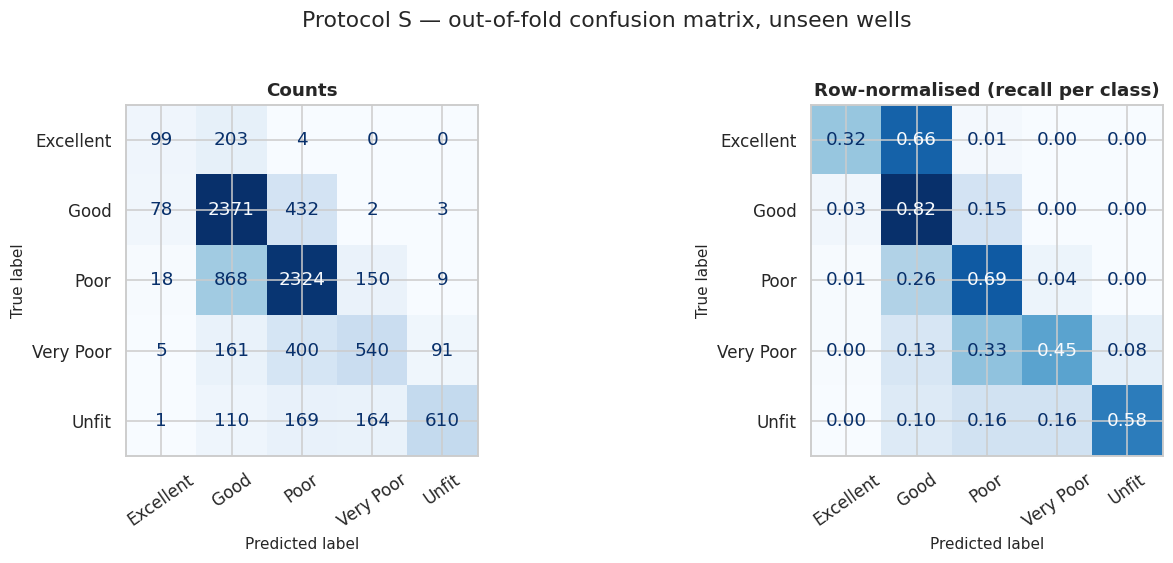

In [85]:
print(classification_report(y, oof_tuned, digits=3))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(y, oof_tuned, labels=WQI_LABELS)
ConfusionMatrixDisplay(cm, display_labels=WQI_LABELS).plot(ax=ax[0], cmap="Blues", colorbar=False, values_format="d")
ax[0].set_title("Counts"); ax[0].tick_params(axis="x", rotation=35)
cmn = cm / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cmn, display_labels=WQI_LABELS).plot(ax=ax[1], cmap="Blues", colorbar=False, values_format=".2f")
ax[1].set_title("Row-normalised (recall per class)"); ax[1].tick_params(axis="x", rotation=35)
plt.suptitle("Protocol S — out-of-fold confusion matrix, unseen wells", y=1.02)
savefig("13_confusion_S")
plt.show()

In [86]:
# Ordinal error: how far off are we, in class steps?
order = {c: i for i, c in enumerate(WQI_LABELS)}
true_ord = pd.Series(y).map(order).to_numpy()
pred_ord = pd.Series(oof_tuned).map(order).to_numpy()
step = np.abs(true_ord - pred_ord)
print(f"Exactly correct        : {(step == 0).mean():.1%}")
print(f"Within ±1 class        : {(step <= 1).mean():.1%}")
print(f"Off by ≥2 classes      : {(step >= 2).mean():.1%}")
print(f"Quadratic-weighted κ   : {cohen_kappa_score(true_ord, pred_ord, weights='quadratic'):.4f}")

Exactly correct        : 67.5%
Within ±1 class        : 94.5%
Off by ≥2 classes      : 5.5%
Quadratic-weighted κ   : 0.7218


In [87]:
# Safety-critical framing: the decision that actually matters is "send this well to the lab, or not"
unsafe = {"Very Poor", "Unfit"}
y_bin    = np.isin(y, list(unsafe)).astype(int)
pred_bin = np.isin(oof_tuned, list(unsafe)).astype(int)
tn, fp, fn, tp = confusion_matrix(y_bin, pred_bin).ravel()
print("Binary screening task  —  'is this water unsafe (Very Poor / Unfit)?'")
print(f"   Recall (unsafe wells caught) : {tp/(tp+fn):.3f}")
print(f"   Precision                    : {tp/(tp+fp):.3f}")
print(f"   Specificity                  : {tn/(tn+fp):.3f}")
print(f"   Missed unsafe wells          : {fn:,} of {tp+fn:,}")
if proba_tuned is not None:
    idx_unsafe = [i for i, c in enumerate(CLASSES) if c in unsafe]
    p_unsafe = proba_tuned[:, idx_unsafe].sum(axis=1)
    print(f"   ROC-AUC on this binary task  : {roc_auc_score(y_bin, p_unsafe):.4f}")

Binary screening task  —  'is this water unsafe (Very Poor / Unfit)?'
   Recall (unsafe wells caught) : 0.624
   Precision                    : 0.895
   Specificity                  : 0.975
   Missed unsafe wells          : 846 of 2,251
   ROC-AUC on this binary task  : 0.8739


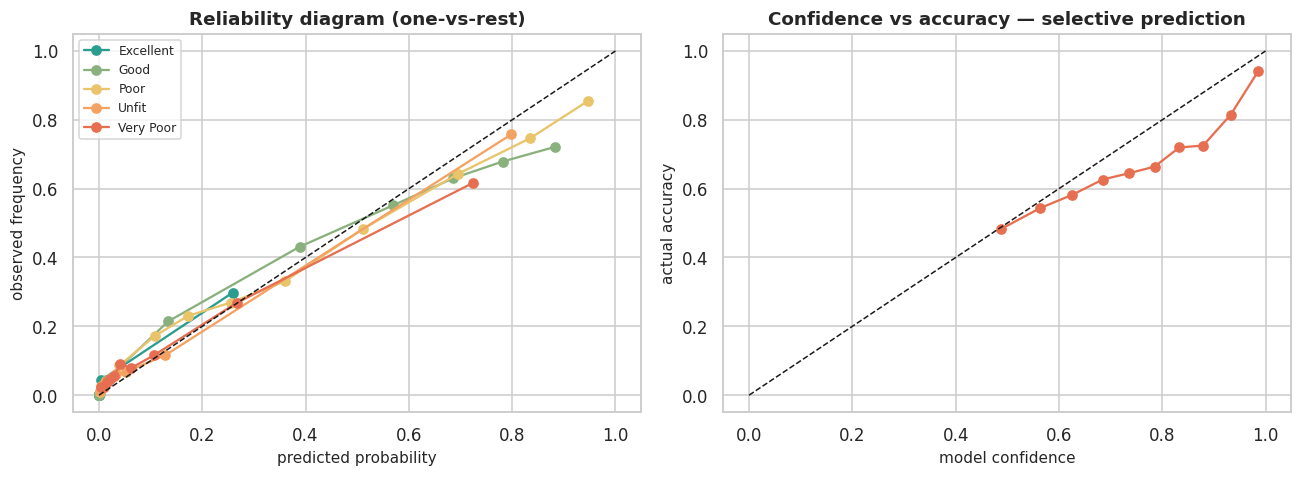

confidence ≥ 0.5 -> covers  94.3% of wells, accuracy 0.688
confidence ≥ 0.6 -> covers  79.5% of wells, accuracy 0.716
confidence ≥ 0.7 -> covers  62.2% of wells, accuracy 0.748
confidence ≥ 0.8 -> covers  41.8% of wells, accuracy 0.797


In [88]:
# Probability calibration — can a field officer trust the confidence number?
if proba_tuned is not None:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
    for i, c in enumerate(CLASSES):
        pt, pp = calibration_curve((y == c).astype(int), proba_tuned[:, i], n_bins=10, strategy="quantile")
        ax[0].plot(pp, pt, "o-", label=c, color=PALETTE[i % len(PALETTE)])
    ax[0].plot([0, 1], [0, 1], "k--", lw=1)
    ax[0].set_xlabel("predicted probability"); ax[0].set_ylabel("observed frequency")
    ax[0].set_title("Reliability diagram (one-vs-rest)"); ax[0].legend(fontsize=8)

    conf = proba_tuned.max(axis=1)
    correct = (oof_tuned == y)
    bins = np.quantile(conf, np.linspace(0, 1, 11))
    mids, accs, ns = [], [], []
    for a, b in zip(bins[:-1], bins[1:]):
        m = (conf >= a) & (conf < b)
        if m.sum() > 20:
            mids.append(conf[m].mean()); accs.append(correct[m].mean()); ns.append(m.sum())
    ax[1].plot(mids, accs, "o-", color="#e76f51"); ax[1].plot([0, 1], [0, 1], "k--", lw=1)
    ax[1].set_xlabel("model confidence"); ax[1].set_ylabel("actual accuracy")
    ax[1].set_title("Confidence vs accuracy — selective prediction")
    savefig("14_calibration")
    plt.show()

    for thr in (0.5, 0.6, 0.7, 0.8):
        m = conf >= thr
        print(f"confidence ≥ {thr:.1f} -> covers {m.mean():6.1%} of wells, accuracy {correct[m].mean():.3f}")

,feature,importance,std
14,logEC,0.5794,0.0061
6,year,0.0982,0.0017
16,EC_x_pH,0.0780,0.0050
13,pH,0.0670,0.0027
11,nn_resid_idw,0.0638,0.0014
3,geo_y,0.0500,0.0018
9,nn_wqi_std,0.0488,0.0011
5,aravalli_dist,0.0452,0.0010
12,nn_dist_km,0.0440,0.0012
0,Latitude,0.0427,0.0011


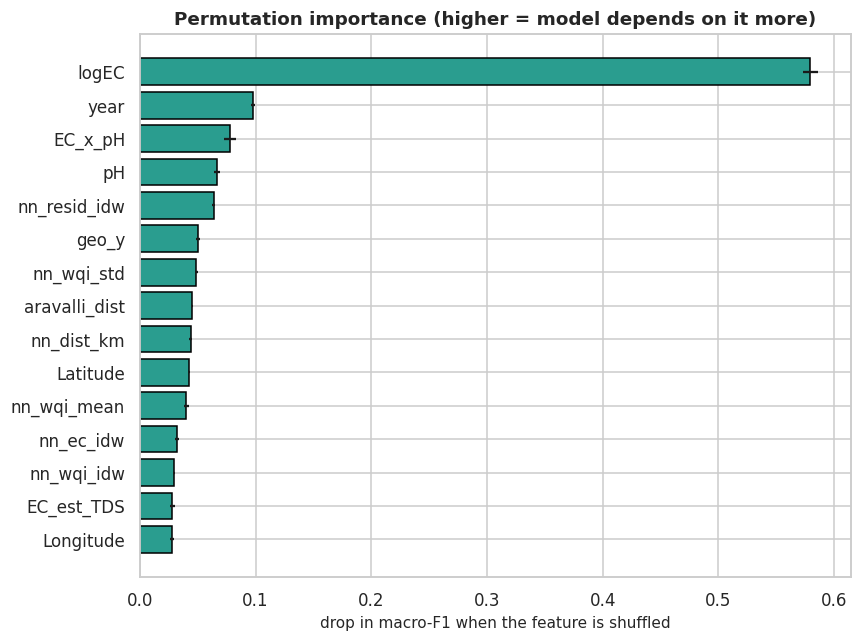

In [89]:
# Fit once on the full search frame for inspection
insp_model = make_tuned().fit(X_search, y)

perm = permutation_importance(insp_model, X_search, y, n_repeats=6,
                              random_state=RANDOM_STATE, scoring="f1_macro", n_jobs=-1)
imp = (pd.DataFrame({"feature": BEST_FEATURES,
                     "importance": perm.importances_mean,
                     "std": perm.importances_std})
       .sort_values("importance", ascending=False))
display(imp.round(4))
imp.to_csv(OUT / "tables" / "permutation_importance.csv", index=False)

plt.figure(figsize=(8, 6))
t = imp.head(15).iloc[::-1]
plt.barh(t["feature"], t["importance"], xerr=t["std"], color="#2a9d8f", edgecolor="black")
plt.xlabel("drop in macro-F1 when the feature is shuffled")
plt.title("Permutation importance (higher = model depends on it more)")
savefig("15_permutation_importance")
plt.show()

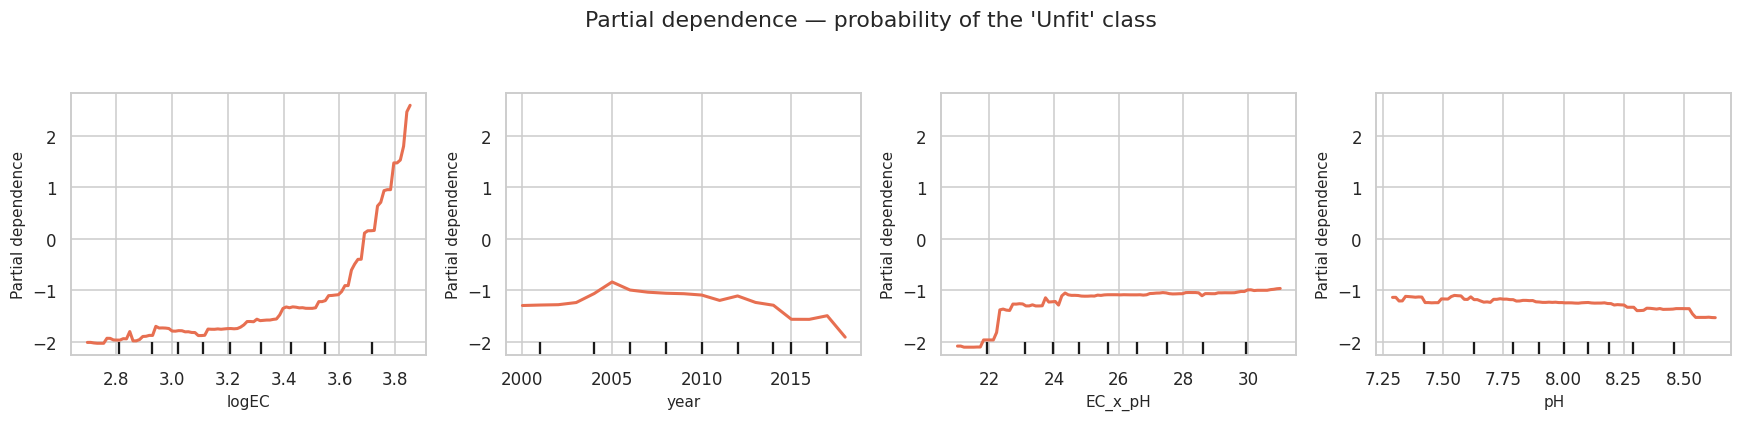

In [90]:
top_feats = imp["feature"].head(4).tolist()
fig, ax = plt.subplots(1, len(top_feats), figsize=(4 * len(top_feats), 3.6))
PartialDependenceDisplay.from_estimator(
    insp_model, X_search, features=top_feats, target="Unfit",
    ax=ax, line_kw={"color": "#e76f51", "lw": 2})
plt.suptitle("Partial dependence — probability of the 'Unfit' class", y=1.06)
savefig("16_pdp")
plt.show()

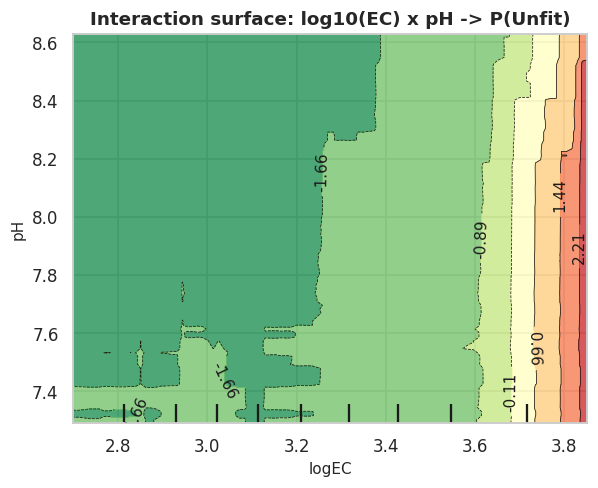

In [91]:
# 2-D interaction: the physically meaningful pH x EC response surface
fig, ax = plt.subplots(figsize=(5.6, 4.6))
PartialDependenceDisplay.from_estimator(
    insp_model, X_search, features=[("logEC", "pH")], target="Unfit",
    ax=ax, kind="average", contour_kw={"cmap": "RdYlGn_r"})
ax.set_title("Interaction surface: log10(EC) x pH -> P(Unfit)")
savefig("17_pdp_interaction")
plt.show()

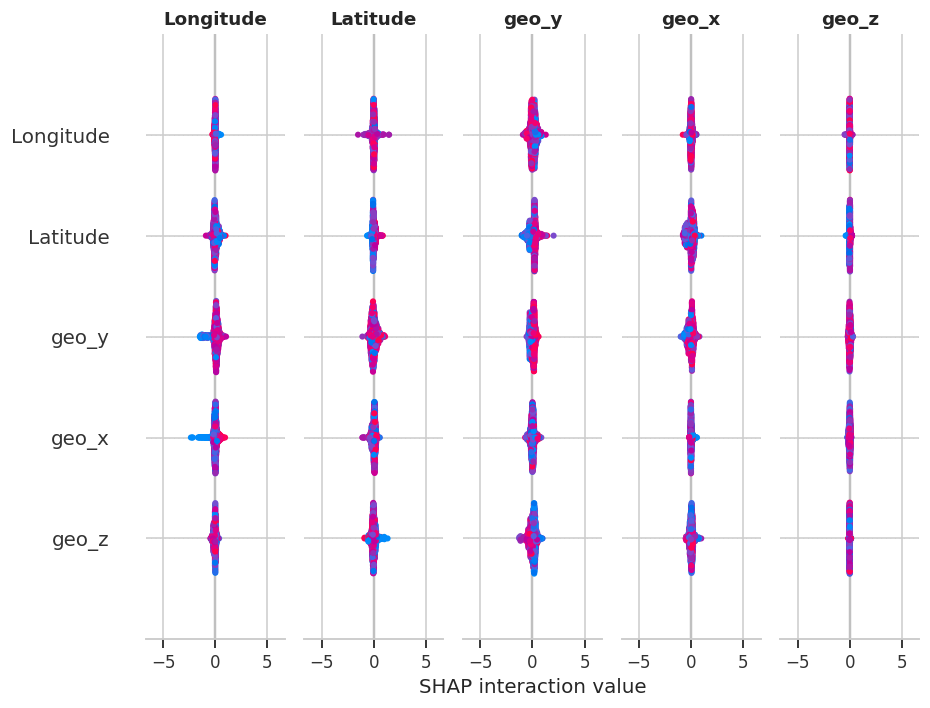

In [92]:
if HAS["shap"]:
    import shap
    sample = X_search.sample(min(1200, len(X_search)), random_state=RANDOM_STATE)
    explainer = shap.TreeExplainer(insp_model)
    sv = explainer.shap_values(sample)
    shap.summary_plot(sv, sample, class_names=list(insp_model.classes_), show=False)
    savefig("18_shap_summary"); plt.show()
else:
    print("SHAP not installed — permutation importance and PDPs above cover the same ground.")
    print("   pip install shap   (then re-run this cell for per-sample attributions)")

In [93]:
SPLIT_YEAR = 2016
tr_T = (df["year"] <= SPLIT_YEAR).to_numpy()
te_T = (df["year"] > SPLIT_YEAR).to_numpy()
print(f"Train: {tr_T.sum():,} samples (≤{SPLIT_YEAR})   Test: {te_T.sum():,} samples (>{SPLIT_YEAR})")
print(f"Test wells already seen in training: "
      f"{df.loc[te_T,'Station'].isin(df.loc[tr_T,'Station']).mean():.1%}")

# k-NN block fitted only on the training period
df_T = df.copy()
idx_tr, idx_te = np.where(tr_T)[0], np.where(te_T)[0]
df_T.loc[df_T.index[idx_tr], KNN_COLS] = spatial_knn_features(df, idx_tr, idx_tr).to_numpy()
df_T.loc[df_T.index[idx_te], KNN_COLS] = spatial_knn_features(df, idx_tr, idx_te).to_numpy()

FEATURES_T = GEO_F + FIELD_F + KNN_COLS + HIST_COLS
assert not set(FEATURES_T) & set(BANNED)
print(f"{len(FEATURES_T)} features for Protocol T")

T_rows, T_preds = [], {}
for label, cols in [("No history (field kit only)", GEO_F + FIELD_F + KNN_COLS),
                    ("With station history",        FEATURES_T)]:
    m = make_tuned()
    m.fit(df_T.loc[tr_T, cols].astype(float), y[tr_T])
    p = m.predict(df_T.loc[te_T, cols].astype(float))
    T_preds[label] = (m, p, cols)
    T_rows.append({"model": label,
                   "accuracy": accuracy_score(y[te_T], p),
                   "balanced_acc": balanced_accuracy_score(y[te_T], p),
                   "macro_F1": f1_score(y[te_T], p, average="macro"),
                   "kappa": cohen_kappa_score(y[te_T], p)})
T = pd.DataFrame(T_rows).set_index("model").round(4)
display(T)
T.to_csv(OUT / "tables" / "protocolT_results.csv")

best_T_label = T["macro_F1"].idxmax()
model_T, pred_T, cols_T = T_preds[best_T_label]
print("\nProtocol T — best configuration:", best_T_label)
print(classification_report(y[te_T], pred_T, digits=3))

Train: 7,637 samples (≤2016)   Test: 1,175 samples (>2016)
Test wells already seen in training: 94.6%
33 features for Protocol T


,accuracy,balanced_acc,macro_F1,kappa
model,,,,
No history (field kit only),0.6919,0.6219,0.6512,0.5580
With station history,0.7123,0.6470,0.6798,0.5866



Protocol T — best configuration: With station history
              precision    recall  f1-score   support

   Excellent      0.672     0.495     0.570        91
        Good      0.683     0.815     0.743       426
        Poor      0.727     0.720     0.723       421
       Unfit      0.881     0.667     0.759       111
   Very Poor      0.687     0.540     0.604       126

    accuracy                          0.712      1175
   macro avg      0.730     0.647     0.680      1175
weighted avg      0.717     0.712     0.709      1175



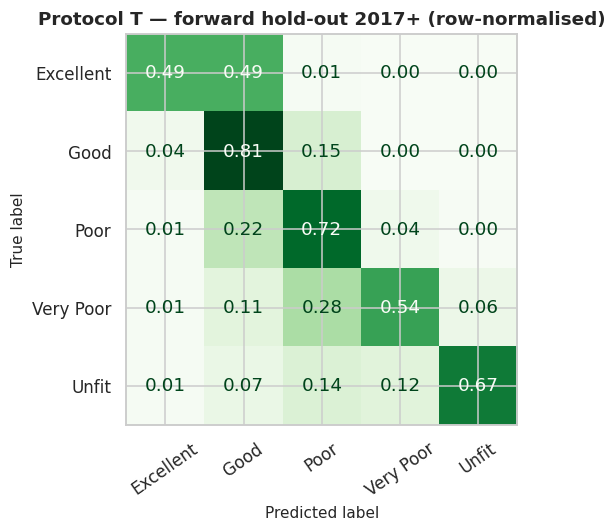

macro-F1 gained by using the well's own monitoring history: +0.029


In [94]:
fig, ax = plt.subplots(figsize=(5.6, 5))
cmT = confusion_matrix(y[te_T], pred_T, labels=WQI_LABELS)
ConfusionMatrixDisplay(cmT / cmT.sum(axis=1, keepdims=True),
                       display_labels=WQI_LABELS).plot(ax=ax, cmap="Greens",
                                                       colorbar=False, values_format=".2f")
ax.set_title(f"Protocol T — forward hold-out {SPLIT_YEAR+1}+ (row-normalised)")
ax.tick_params(axis="x", rotation=35)
savefig("19_confusion_T")
plt.show()

hist_gain = T.loc["With station history", "macro_F1"] - T.loc["No history (field kit only)", "macro_F1"]
print(f"macro-F1 gained by using the well's own monitoring history: {hist_gain:+.3f}")

In [95]:
SAR_FEATURES = GEO_F + FIELD_F + KNN_COLS
y_sar = np.log10(df["SAR"].clip(lower=0.05))          # log target: SAR is strongly right-skewed
X_sar = df_search[SAR_FEATURES].astype(float)
ALPHA = 0.20                                           # target 80% prediction intervals

def hgbr(q=None, **kw):
    p = dict(max_iter=350, learning_rate=0.06, max_leaf_nodes=63,
             min_samples_leaf=15, l2_regularization=1.0, random_state=RANDOM_STATE)
    p.update(kw)
    if q is not None:
        return HistGradientBoostingRegressor(loss="quantile", quantile=q, **p)
    return HistGradientBoostingRegressor(**p)

oof_med = np.zeros(len(df))
oof_lo_raw, oof_hi_raw = np.zeros(len(df)), np.zeros(len(df))
oof_lo_cqr, oof_hi_cqr = np.zeros(len(df)), np.zeros(len(df))

for tr, te in GroupKFold(n_splits=5).split(df, y_sar, groups=groups):
    # station-disjoint fit / calibration split inside the training fold
    wells = np.unique(groups[tr])
    rng = np.random.RandomState(RANDOM_STATE)
    cal_wells = set(rng.choice(wells, size=int(0.30 * len(wells)), replace=False))
    is_cal = np.isin(groups[tr], list(cal_wells))
    fit_idx, cal_idx = tr[~is_cal], tr[is_cal]

    m_lo = hgbr(q=ALPHA / 2).fit(X_sar.iloc[fit_idx], y_sar.iloc[fit_idx])
    m_hi = hgbr(q=1 - ALPHA / 2).fit(X_sar.iloc[fit_idx], y_sar.iloc[fit_idx])
    m_md = hgbr().fit(X_sar.iloc[fit_idx], y_sar.iloc[fit_idx])

    lo_c, hi_c = m_lo.predict(X_sar.iloc[cal_idx]), m_hi.predict(X_sar.iloc[cal_idx])
    E = np.maximum(lo_c - y_sar.iloc[cal_idx], y_sar.iloc[cal_idx] - hi_c)
    n = len(cal_idx)
    Q = np.quantile(E, min(1.0, np.ceil((n + 1) * (1 - ALPHA)) / n))

    oof_med[te]    = m_md.predict(X_sar.iloc[te])
    oof_lo_raw[te] = m_lo.predict(X_sar.iloc[te])
    oof_hi_raw[te] = m_hi.predict(X_sar.iloc[te])
    oof_lo_cqr[te] = oof_lo_raw[te] - Q
    oof_hi_cqr[te] = oof_hi_raw[te] + Q

sar_true, sar_pred = 10 ** y_sar.to_numpy(), 10 ** oof_med
cov_raw = float(((y_sar >= oof_lo_raw) & (y_sar <= oof_hi_raw)).mean())
cov_cqr = float(((y_sar >= oof_lo_cqr) & (y_sar <= oof_hi_cqr)).mean())

reg = {
    "R2 (log space)":    r2_score(y_sar, oof_med),
    "R2 (SAR units)":    r2_score(sar_true, sar_pred),
    "MAE (SAR units)":   mean_absolute_error(sar_true, sar_pred),
    "RMSE (SAR units)":  mean_squared_error(sar_true, sar_pred) ** 0.5,
    "MedAE (SAR units)": float(np.median(np.abs(sar_true - sar_pred))),
    "coverage raw quantile":  cov_raw,
    "coverage after CQR":     cov_cqr,
    "nominal coverage":       1 - ALPHA,
}
display(pd.Series(reg).round(4).to_frame("Protocol S (grouped CV)"))
print(f"\nCQR repaired the interval: {cov_raw:.1%} -> {cov_cqr:.1%} against a nominal {1-ALPHA:.0%} target.")

,Protocol S (grouped CV)
R2 (log space),0.7071
R2 (SAR units),0.5975
MAE (SAR units),3.0769
RMSE (SAR units),5.0415
MedAE (SAR units),1.6413
coverage raw quantile,0.5668
coverage after CQR,0.7973
nominal coverage,0.8000



CQR repaired the interval: 56.7% -> 79.7% against a nominal 80% target.


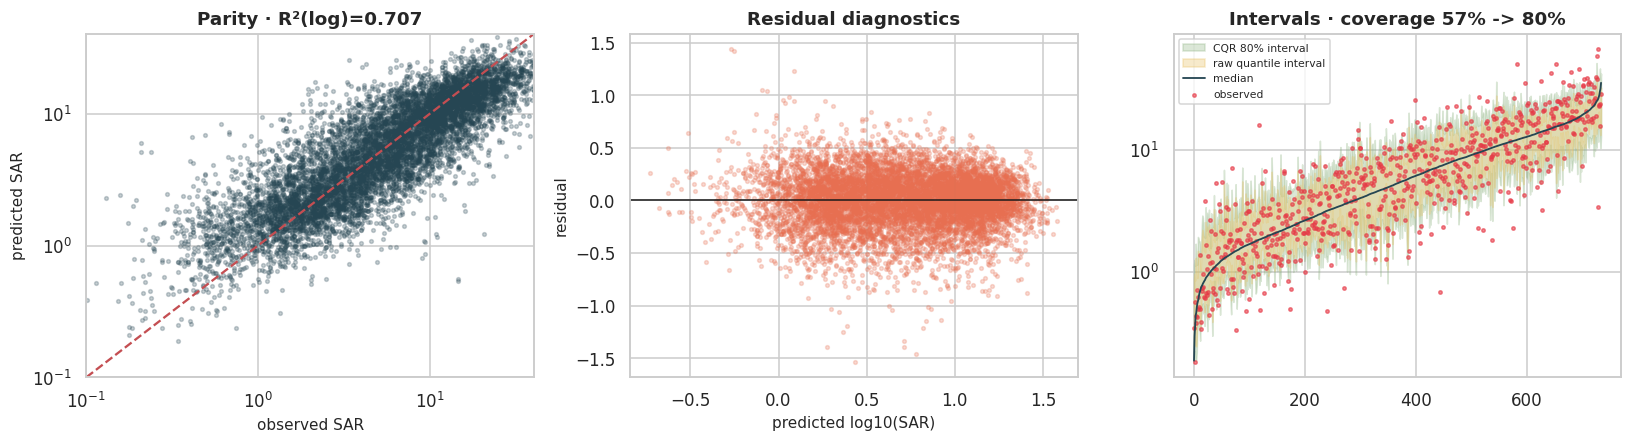

In [96]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
ax[0].scatter(sar_true, sar_pred, s=6, alpha=.25, color="#264653")
lim = [0.1, np.percentile(sar_true, 99.5)]
ax[0].plot(lim, lim, "r--"); ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlim(lim); ax[0].set_ylim(lim)
ax[0].set_xlabel("observed SAR"); ax[0].set_ylabel("predicted SAR")
ax[0].set_title(f"Parity · R²(log)={reg['R2 (log space)']:.3f}")

resid = y_sar.to_numpy() - oof_med
ax[1].scatter(oof_med, resid, s=6, alpha=.25, color="#e76f51"); ax[1].axhline(0, c="k", lw=1)
ax[1].set_xlabel("predicted log10(SAR)"); ax[1].set_ylabel("residual")
ax[1].set_title("Residual diagnostics")

o = np.argsort(oof_med)[::12]
xs = range(len(o))
ax[2].fill_between(xs, 10 ** oof_lo_cqr[o], 10 ** oof_hi_cqr[o], alpha=.30,
                   color="#8ab17d", label=f"CQR {1-ALPHA:.0%} interval")
ax[2].fill_between(xs, 10 ** oof_lo_raw[o], 10 ** oof_hi_raw[o], alpha=.35,
                   color="#e9c46a", label="raw quantile interval")
ax[2].plot(xs, 10 ** oof_med[o], lw=1.2, color="#264653", label="median")
ax[2].scatter(xs, sar_true[o], s=5, color="#e63946", alpha=.6, label="observed")
ax[2].set_yscale("log"); ax[2].legend(fontsize=7)
ax[2].set_title(f"Intervals · coverage {cov_raw:.0%} -> {cov_cqr:.0%}")
savefig("20_sar_regression")
plt.show()

In [97]:
# Does the regression translate into correct irrigation advice?
def sar_hazard(v):
    return pd.cut(v, [-np.inf, 10, 18, 26, np.inf], labels=["S1 low", "S2 medium", "S3 high", "S4 very high"])

haz_true, haz_pred = sar_hazard(sar_true), sar_hazard(sar_pred)
print("Sodicity-hazard class recovered from the regression:")
print(classification_report(haz_true.astype(str), haz_pred.astype(str), digits=3))
print(f"Operational accuracy of the S-class advice: {(haz_true == haz_pred).mean():.1%}")

Sodicity-hazard class recovered from the regression:
              precision    recall  f1-score   support

      S1 low      0.884     0.911     0.897      6130
   S2 medium      0.456     0.533     0.492      1671
     S3 high      0.320     0.227     0.266       664
S4 very high      0.414     0.084     0.139       347

    accuracy                          0.755      8812
   macro avg      0.519     0.439     0.449      8812
weighted avg      0.742     0.755     0.743      8812

Operational accuracy of the S-class advice: 75.5%


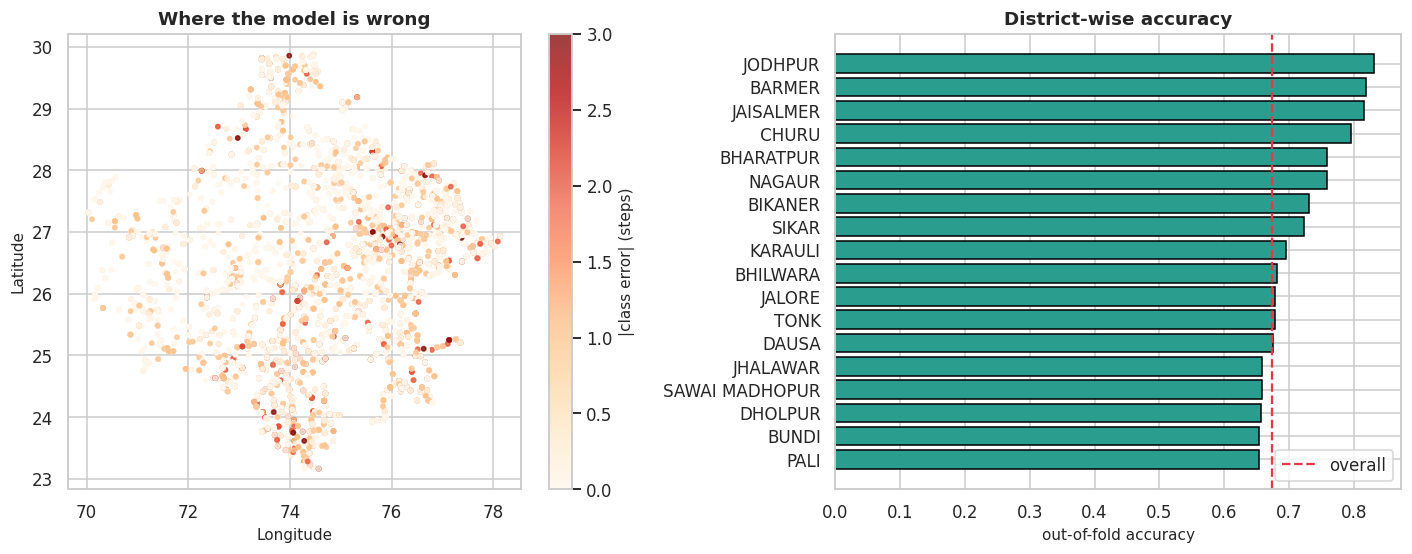

,n,acc
district,,
PRATAPGARH,71,0.451
BARAN,210,0.457
DUNGARPUR,222,0.577
CHITTORGARH,244,0.582
RAJSAMAND,293,0.587
SIROHI,202,0.594
KOTA,216,0.602
JAIPUR,411,0.606


In [98]:
err = pd.DataFrame({"lat": df["Latitude"], "lon": df["Longitude"],
                    "district": df["District"], "correct": (oof_tuned == y).astype(int),
                    "step": step})
fig, ax = plt.subplots(1, 2, figsize=(13, 5.2))
sc = ax[0].scatter(err["lon"], err["lat"], c=err["step"], cmap="OrRd", s=8, alpha=.75, vmin=0, vmax=3)
plt.colorbar(sc, ax=ax[0], label="|class error| (steps)")
ax[0].set_title("Where the model is wrong")
ax[0].set_xlabel("Longitude"); ax[0].set_ylabel("Latitude")

acc_d = (err.groupby("district")
           .agg(n=("correct", "size"), acc=("correct", "mean"))
           .query("n >= 60").sort_values("acc"))
ax[1].barh(acc_d.index[-18:], acc_d["acc"][-18:], color="#2a9d8f", edgecolor="black")
ax[1].axvline(err["correct"].mean(), color="#e63946", ls="--", label="overall")
ax[1].set_xlabel("out-of-fold accuracy"); ax[1].set_title("District-wise accuracy"); ax[1].legend()
savefig("21_error_map")
plt.show()

display(acc_d.head(8).round(3))

In [99]:
FINAL_FEATURES = BEST_FEATURES
final_model = make_tuned().fit(X_search, y)

ARTEFACT = {
    "model": final_model,
    "features": FINAL_FEATURES,
    "classes": list(final_model.classes_),
    "knn_reference": df[["Station", "Latitude", "Longitude", "WQI", "logEC"]].copy(),
    "bis_standard": BIS_STANDARD,
    "assigned_weights": ASSIGNED_W,
    "wqi_bins": WQI_BINS,
    "wqi_labels": WQI_LABELS,
    "trained_on": {"n_samples": int(len(df)), "n_stations": int(df["Station"].nunique()),
                   "years": [int(df["year"].min()), int(df["year"].max())]},
    "protocolS_metrics": r_tuned,
    "sklearn_version": sklearn.__version__,
}
path = OUT / "models" / "gwq_rajasthan_wqi_classifier.joblib"
joblib.dump(ARTEFACT, path, compress=3)
print(f"Saved {path}  ({path.stat().st_size/1e6:.2f} MB)")

Saved outputs/models/gwq_rajasthan_wqi_classifier.joblib  (1.75 MB)


In [102]:
def predict_water_quality(pH, EC, latitude, longitude, year=2025, artefact=None, k=20):
    """
    Field-screening inference.

    Inputs are exactly what a handheld meter + phone GPS provide.
    Returns the predicted BIS drinking-water class, its probability, and a lab-referral recommendation.
    """
    A = artefact or ARTEFACT
    ref = A["knn_reference"]

    row = {
        "Latitude": latitude, "Longitude": longitude, "year": year,
        "geo_x": np.cos(np.radians(latitude)) * np.cos(np.radians(longitude)),
        "geo_y": np.cos(np.radians(latitude)) * np.sin(np.radians(longitude)),
        "geo_z": np.sin(np.radians(latitude)),
        "aravalli_dist": abs(1.12 * latitude - longitude + 45.17) / np.sqrt(1.12 ** 2 + 1),
        "pH": pH, "logEC": np.log10(EC), "pH_dev": pH - 7.0,
        "EC_x_pH": np.log10(EC) * pH, "EC_est_TDS": 0.65 * EC,
    }

    tree = BallTree(np.radians(ref[["Latitude", "Longitude"]].to_numpy()), metric="haversine")
    d, i = tree.query(np.radians([[latitude, longitude]]), k=min(k, len(ref)))
    d_km = d[0] * EARTH_R_KM
    w = 1.0 / (d_km + 1e-3)
    t = np.log10(ref["WQI"].to_numpy()[i[0]])
    e = ref["logEC"].to_numpy()[i[0]]
    row.update(dict(zip(KNN_COLS, [np.average(t, weights=w), t.mean(), t.std(),
                                   np.average(e, weights=w), np.average(t - e, weights=w), d_km.mean()])))

    X = pd.DataFrame([row])[A["features"]].astype(float)
    proba = A["model"].predict_proba(X)[0]
    cls = A["classes"][int(np.argmax(proba))]
    conf = float(proba.max())
    unsafe_p = float(sum(p for c, p in zip(A["classes"], proba) if c in ("Very Poor", "Unfit")))

    if conf < 0.60 or unsafe_p > 0.25:
        action = "SEND TO LABORATORY — uncertain or elevated risk"
    elif cls in ("Very Poor", "Unfit"):
        action = "SEND TO LABORATORY — predicted unfit for drinking"
    else:
        action = "No immediate lab referral — re-screen at next campaign"

    return {"predicted_class": cls, "confidence": round(conf, 3),
            "P(unsafe)": round(unsafe_p, 3), "recommendation": action,
            "class_probabilities": {c: round(float(p), 3) for c, p in zip(A["classes"], proba)}}

In [101]:
# Demo — three real wells held out from the narrative, plus one hypothetical saline well
demo = [
    dict(pH=7.8, EC=620,   latitude=26.90, longitude=75.80, year=2025),   # Jaipur, fresh
    dict(pH=8.3, EC=3400,  latitude=27.20, longitude=71.60, year=2025),   # Jaisalmer belt, brackish
    dict(pH=8.6, EC=11500, latitude=29.10, longitude=73.40, year=2025),   # Ganganagar, saline
    dict(pH=7.2, EC=250,   latitude=24.60, longitude=73.70, year=2025),   # Udaipur hills, very fresh
]
for d_ in demo:
    out_ = predict_water_quality(**d_)
    print(f"pH {d_['pH']:>4}  EC {d_['EC']:>6} µS/cm  @ ({d_['latitude']}, {d_['longitude']})")
    print(f"   -> {out_['predicted_class']:<10} conf={out_['confidence']:.2f}  "
          f"P(unsafe)={out_['P(unsafe)']:.2f}")
    print(f"      {out_['recommendation']}\n")

pH  7.8  EC    620 µS/cm  @ (26.9, 75.8)
   -> Good       conf=0.68  P(unsafe)=0.00
      No immediate lab referral — re-screen at next campaign

pH  8.3  EC   3400 µS/cm  @ (27.2, 71.6)
   -> Poor       conf=0.91  P(unsafe)=0.09
      No immediate lab referral — re-screen at next campaign

pH  8.6  EC  11500 µS/cm  @ (29.1, 73.4)
   -> Unfit      conf=0.99  P(unsafe)=0.99
      SEND TO LABORATORY — uncertain or elevated risk

pH  7.2  EC    250 µS/cm  @ (24.6, 73.7)
   -> Good       conf=0.92  P(unsafe)=0.01
      No immediate lab referral — re-screen at next campaign



In [103]:
# Round-trip test: reload the artefact from disk and confirm identical behaviour
reloaded = joblib.load(path)
chk = predict_water_quality(7.9, 1800, 26.5, 74.2, 2025, artefact=reloaded)
print("Reloaded artefact works:", chk["predicted_class"], chk["confidence"])

Reloaded artefact works: Poor 0.857


## 18 · Results summary

In [104]:
summary = pd.DataFrame([
    {"Task": "1 · WQI class, unseen well",  "Protocol": "Grouped CV (station)",
     "Model": "Tuned HistGradientBoosting",
     "Headline": f"macro-F1 {r_tuned['macro_F1']:.3f}",
     "Secondary": f"acc {r_tuned['accuracy']:.3f} · κ {r_tuned['kappa']:.3f} · "
                  f"±1 class {(step<=1).mean():.1%}"},
    {"Task": "2 · WQI class, monitored well next visit", "Protocol": f"Temporal hold-out >{SPLIT_YEAR}",
     "Model": "Tuned HGB + station history",
     "Headline": f"macro-F1 {T.loc[best_T_label,'macro_F1']:.3f}",
     "Secondary": f"acc {T.loc[best_T_label,'accuracy']:.3f} · κ {T.loc[best_T_label,'kappa']:.3f}"},
    {"Task": "3 · SAR (irrigation sodicity)", "Protocol": "Grouped CV (station)",
     "Model": "HGB + Conformalized Quantile Regression",
     "Headline": f"R² {reg['R2 (log space)']:.3f}",
     "Secondary": f"MAE {reg['MAE (SAR units)']:.2f} · CQR coverage {reg['coverage after CQR']:.1%}"},
]).set_index("Task")
display(summary)
summary.to_csv(OUT / "tables" / "final_summary.csv")

print("\nData pipeline:")
print(f"   raw records                 : {len(raw):,}")
print(f"   after plausibility + panel  : {n0:,}")
print(f"   after charge-balance QA     : {len(df):,}  ({df['Station'].nunique():,} wells, "
      f"{df['year'].min()}–{df['year'].max()})")

,Protocol,Model,Headline,Secondary
Task,,,,
"1 · WQI class, unseen well",Grouped CV (station),Tuned HistGradientBoosting,macro-F1 0.604,acc 0.675 · κ 0.531 · ±1 class 94.5%
"2 · WQI class, monitored well next visit",Temporal hold-out >2016,Tuned HGB + station history,macro-F1 0.680,acc 0.712 · κ 0.587
3 · SAR (irrigation sodicity),Grouped CV (station),HGB + Conformalized Quantile Regression,R² 0.707,MAE 3.08 · CQR coverage 79.7%



Data pipeline:
   raw records                 : 12,350
   after plausibility + panel  : 9,408
   after charge-balance QA     : 8,812  (1,417 wells, 2000–2018)




**Data source:** Central Ground Water Board (CGWB), Ministry of Jal Shakti, Government of India — manual
groundwater quality monitoring, Rajasthan. Standards: BIS 10500:2012; USSL (Richards 1954); APHA 1030E.